# Machine Learning Model Testing

Notebook 5 tested SARIMAX models and notebook 6 built the features. This notebook tests
**Machine Learning regressors** on the same series (monthly international arrivals to
Brazil, aggregated over all routes, origins and destinations) with the **same protocol as
notebook 5**:

- Every configuration is trained and scored at **four validation origins** (two before the
  pandemic, the two most recent years after it), each forecasting the next 12 months. The latest origin forecasts
  the validation set (`val.parquet`).
- Configurations are ranked by the **mean seasonal MASE over the origins**, and every
  configuration becomes one MLflow run.
- The **test set is never read here**. The final notebook refits the selected configuration
  and evaluates it once on the test year.

The grid crosses six choices:

| Choice | Options |
|---|---|
| **Model family** | Ridge, Lasso, LightGBM, XGBoost |
| **Target processing** | `none`, `log`, `auto_stationary` (as in notebook 5) and `seasonal_log_diff` |
| **Training window** | all history, the last 14 / 12 / 10 / 8 / 6 / 4 years, post-COVID (as in notebook 5) |
| **COVID rows** | `keep` the pandemic years, or `remove` 2020–2022 from the series |
| **Multi-step strategy** | recursive, direct with a single model |
| **Feature set** | six combinations of lags, month-over-month growth, rolling statistics, domain flags, calendar and elapsed time |

The best grid configuration of every **tree family × training window** group is then
**tuned with Optuna** on the same objective (mean seasonal MASE over the origins).

Choosing among thousands of configurations on validation data makes the top validation
scores optimistic. Four origins (48 validation months instead of 12) reduce this, and the test
year stays apart for an unbiased final score. Notebooks 5 and 7 share the origins, the metrics
and the baselines, so their rankings are comparable.

Global models on the disaggregated series are tested in a separate notebook.

## Setup

In [2]:
import itertools
import json
import logging
import math
import os
import sys
import time
import warnings
from concurrent.futures import ThreadPoolExecutor
from typing import NamedTuple

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from category_encoders import OneHotEncoder
from dotenv import load_dotenv
from IPython.display import display
from joblib import Parallel, delayed, parallel_config
from lightgbm import LGBMRegressor, early_stopping
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.metrics import r2_score
from sklearn.model_selection import TimeSeriesSplit
from tqdm import tqdm
from xgboost import XGBRegressor

load_dotenv()

ROOT_PATH = os.path.dirname(os.getcwd())
DATA_FOLDER_PATH = os.path.join(ROOT_PATH, 'data', 'processed')

COVID_START = pd.Timestamp('2020-04-01')  # first pandemic month: April 2020
COVID_END = pd.Timestamp('2021-12-31')
POST_COVID_START = pd.Timestamp('2022-01-01')
COVID_RECOVERY_END = pd.Timestamp('2022-06-30')

TARGET = 'arrival_count'  # original scale (arrivals)
Y = 'y'  # model scale (after the target processing)
TS_ID = 'series_id'
SERIES_ID = 'brazil_total'
FREQ = 'ME'
SEASONAL_PERIOD = 12
RANDOM_STATE = 42

# physical cores: the fits are small and CPU-bound
N_JOBS = max(1, (os.cpu_count() or 2) // 2)

sns.set_palette('colorblind')
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)
logging.getLogger('mlflow').setLevel(logging.ERROR)
warnings.filterwarnings('ignore', category=FutureWarning)
mlflow.set_tracking_uri(os.getenv('MLFLOW_TRACKING_URI'))
EXPERIMENT_NAME = 'Brazil Tourism Forecasting ML'
experiment = mlflow.set_experiment(EXPERIMENT_NAME)

### Book Helpers

The training and feature helpers come from the companion repository of:

> Joseph, M. & Tackes, J. *Modern Time Series Forecasting with Python*, 2nd ed.
> (Packt, 2024) — [PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E](https://github.com/PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E), MIT License

| Helper | Module | Used for |
|---|---|---|
| `FeatureConfig`, `MissingValueConfig`, `ModelConfig` | `src/forecasting/ml_forecasting.py` | Which columns are features, how to fill gaps, how to scale and encode |
| `MLForecast` | `src/forecasting/ml_forecasting.py` | Wrapper around any scikit-learn regressor: fit, predict, feature importance |
| `calculate_metrics` | `src/forecasting/ml_forecasting.py` | MAE, MSE and Forecast Bias (the MASE used here is seasonal, section 4) |
| `add_lags`, `add_rolling_features`, `add_seasonal_rolling_features`, `add_ewma` | `src/feature_engineering/autoregressive_features.py` | Target-derived features |
| `add_temporal_features`, `add_fourier_features` | `src/feature_engineering/temporal_features.py` | Calendar, elapsed time and Fourier terms |
| `AutoStationaryTransformer` | `src/transforms/target_transformations.py` | AutoML target processing (notebook 5) |

Notes on using them here:

- The book's `MLForecast` wraps scikit-learn estimators. It is **not** the `mlforecast`
  library from Nixtla.
- `evaluate_model` in chapter 8 builds `MLForecast` from the **global** `feat_config` and
  `missing_value_config` instead of its own arguments, so every feature set would silently use
  the same features. The version below (`fit_model`) uses its arguments.
- `ModelConfig.categorical_encoder` must expose a `cols` attribute: the `OneHotEncoder` of the
  `category_encoders` package, not scikit-learn's.
- `MLForecast.predict` checks the training columns **before** it applies the categorical
  encoding, so every one-hot model fails at prediction time. The subclass `MLForecastFixed`
  (section 3) runs the same check on the input columns.
- `FeatureConfig.get_X_y` returns its columns in `set` order, which changes from one process to
  the next and makes the tree models' column subsampling irreproducible. `feature_matrix`
  sorts the columns.
- The target processing is applied to the series **before** the features are built, so lags,
  rolling windows and the target share one scale. `MLForecast(target_transformer=...)` would
  only transform `y`.
- Importing `ml_forecasting` pulls in the book's `src.utils`, which imports `torch`,
  `pytorch_lightning`, `humanize` and `datasetsforecast` (< 1.0). They are project dependencies
  for this reason.
- As in notebook 6: `ts_id` is always passed, `add_ewma` gets `spans`, and
  `add_fourier_features` gets `max_value`.

In [3]:
# Helpers credited to: Joseph, M. & Tackes, J. "Modern Time Series Forecasting with
# Python", 2nd ed. (Packt, 2024) — MIT License
# github.com/PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E
MTSF_REPO_PATH = os.getenv(
    'MTSF_REPO_PATH',
    os.path.join(
        os.path.dirname(ROOT_PATH), 'Modern-Time-Series-Forecasting-with-Python-2E'
    ),
)
if MTSF_REPO_PATH not in sys.path:
    sys.path.insert(0, MTSF_REPO_PATH)

from src.feature_engineering.autoregressive_features import (  # noqa: E402
    add_ewma,
    add_lags,
    add_rolling_features,
    add_seasonal_rolling_features,
)
from src.feature_engineering.temporal_features import (  # noqa: E402
    add_fourier_features,
    add_temporal_features,
)
from src.forecasting.ml_forecasting import (  # noqa: E402
    FeatureConfig,
    MissingValueConfig,
    MLForecast,
    ModelConfig,
    calculate_metrics,
)
from src.transforms.target_transformations import (  # noqa: E402
    AutoStationaryTransformer,
)

### Target Processing

The three options of notebook 5 plus a fourth one. The model learns and predicts on the
**transformed** scale, and every forecast is inverse-transformed to arrivals before scoring.

| Option | Transform | Inverse |
|---|---|---|
| `none` | identity | identity |
| `log` | `log(y)` | `exp(ŷ)` |
| `auto_stationary` | `AutoStationaryTransformer`: detrend / deseasonalize / Box-Cox, each step only when its test asks for it | exact `inverse_transform` of the fitted pipeline |
| `seasonal_log_diff` | `z_t = log(y_t) − log(y_{t−12})`, the yearly growth rate | `ŷ_t = y_{t−12} · exp(ẑ_t)` |

**Why a fourth option.** A tree never predicts above the largest target it saw in training, and
forecasting a trending series is extrapolation, so gradient-boosted trees are expected to fail on
a strong trend unless they are trained on data without it (Joseph & Tackes, ch. 5–6). The
`AutoStationaryTransformer` leaves differencing out on purpose, and the book notes that for
autoregressive series differencing does a lot and deserves its own transformation.

`seasonal_log_diff` gives the ML models what `log` + `D = 1` gives SARIMAX in notebook 5: the
model predicts the **yearly growth**, which stays in the range seen in training even when the
level is at a record (the 2022–23 rebound has growth far above +40%). Its lags and rolling
windows become "recent growth", the momentum signal the level features miss.

How it is built (a small class with the interface of `LogTarget`, like the book's
`AdditiveDifferencingTransformer(diff_gap=12)` applied to the log; the book's class uses
`Series.append`, removed in pandas 2):

- The difference is **positional**, like the book's `diff_gap`. With `remove`, the spliced
  series differences January 2023 against January 2019, twelve rows earlier.
- The inverse takes `y_{t−12}` from the last 12 months of the history the transformer was
  fitted on. With `HORIZON` = 12, every base value of the forecast is known, so the inverse is
  exact for both strategies, including the recursive one.
- The first 12 rows have no difference and are dropped with the warm-up rows.
- With `keep`, the pandemic growth rates reach about ±4 on the log scale; the Optuna step can
  pick a Huber or L1 objective for the trees, which is less sensitive to them.

Why it matters for trees: a tree only predicts values inside the range of its training
targets. On the raw scale, LightGBM and XGBoost cannot forecast arrivals above the historical
maximum.

In [4]:
TARGET_TRANSFORMS = ['none', 'log', 'auto_stationary', 'seasonal_log_diff']


def fit_auto_stationary(train_series):
    """Fit a fresh AutoStationaryTransformer (Mann-Kendall trend, Guerrero Box-Cox)."""
    # fresh dicts every fit: the transformer mutates its parameter dicts in place
    transformer = AutoStationaryTransformer(
        confidence=0.05,
        seasonal_period=SEASONAL_PERIOD,
        trend_check_params={'mann_kendall': True},
        detrender_params={'degree': 1},
        deseasonalizer_params={},
        box_cox_params={'optimization': 'guerrero'},
    )
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        return transformer.fit(train_series, freq=FREQ)


class IdentityTarget:
    """No target transformation."""

    @staticmethod
    def transform(y):
        return y

    @staticmethod
    def inverse_transform(y):
        return y


class LogTarget:
    """Natural log of the arrival counts; inverse is exp."""

    @staticmethod
    def transform(y):
        return np.log(y)

    @staticmethod
    def inverse_transform(y):
        return np.exp(y)


class SeasonalLogDiffTarget:
    """Seasonal difference of the log: z_t = log(y_t) - log(y_{t-12}).

    Positional, like the book's `AdditiveDifferencingTransformer(diff_gap=12)`. The
    inverse takes y_{t-12} from the last `period` months of the fitted history, so it is
    exact for forecasts up to `period` months after the end of that history.
    """

    def __init__(self, train_series, period=SEASONAL_PERIOD):
        self.period = period
        self.log_history = np.log(train_series.astype(float)).to_numpy()
        self.last_date = train_series.index[-1]

    def transform(self, y):
        log_y = np.log(y.astype(float))
        return log_y - log_y.shift(self.period)

    def inverse_transform(self, z):
        dates = pd.DatetimeIndex(z.index)
        steps = (dates.year - self.last_date.year) * 12 + (
            dates.month - self.last_date.month
        )
        assert ((steps >= 1) & (steps <= self.period)).all(), 'up to one season ahead'
        base = self.log_history[len(self.log_history) - self.period + steps - 1]
        return pd.Series(np.exp(np.asarray(z, dtype=float) + base), index=z.index)


def fit_target_transform(name, train_series):
    """Return a fitted transformer exposing `transform` / `inverse_transform`."""
    if name == 'none':
        return IdentityTarget()
    if name == 'log':
        return LogTarget()
    if name == 'auto_stationary':
        return fit_auto_stationary(train_series)
    if name == 'seasonal_log_diff':
        return SeasonalLogDiffTarget(train_series)
    raise ValueError(f'unknown target transform: {name}')


def describe_transform(name, transformer):
    if name != 'auto_stationary':
        return name
    steps = [
        type(tr).__name__.replace('Transformer', '') for tr in transformer._pipeline
    ]
    return ' → '.join(steps) if steps else '(none)'

## 1. Data, Validation Origins, Training Windows and COVID Rows

**Data.** Monthly totals from `train.parquet` and `val.parquet`, the same aggregation as
notebooks 5 and 6. `HORIZON` and every date below are read from the files. The test set is
never read.

**Validation origins** (repeated holdout without overlap, the same origins as notebook 5). A
single validation year can reward the quirks of that year on a non-stationary series, so every
configuration is trained and scored at several origins (ch. 19):

- the end of training (its window is `val.parquet`) and one year earlier: always the two
  most recent years of the data;
- the two most recent yearly origins whose 12-month validation window ends **before** the
  pandemic.

Each origin only sees the history up to that origin: the training windows, the target
processing and the features are all rebuilt from it. Only the counts are fixed
(`N_PRE_COVID_ORIGINS`, `N_POST_COVID_ORIGINS`): the dates are counted back from the end of
training, so the post-COVID origins always follow the newest data.

**Training windows** (notebook 5, counted back from the origin). A window selects the **rows
that train the model**; the features still read the whole history, since a row of 2022 needs
lags up to 36 months back.

| Window | Training rows |
|---|---|
| `all` | the whole history (from the first month with complete features, 1992) |
| `last_14y` … `last_4y` | the last N years before the origin |
| `post_covid` | January 2022 onwards (only exists at the post-COVID origins) |

**COVID rows.** Two ways to deal with the pandemic:

- `keep`: the series is used as it is. The `domain` group flags the COVID months, the recovery
  months and the lags that point into the pandemic (notebook 6).
- `remove`: the years **2020 to 2022** are cut out of the series **before** the target
  processing, and the features are built on the remaining months. December 2019 is then
  followed by January 2023. Three full years are removed, so the month alignment of every
  seasonal lag is preserved: the `lag_12` of January 2023 is January 2019. The COVID flags no
  longer apply and are replaced by flags that mark the lags **crossing the removed gap**.

Before the pandemic there is nothing to remove, so at the pre-COVID origins `remove` is the same
model as `keep` (fitted once, scored for both). `post_covid` has no pandemic rows to remove, so
it only runs with `keep`.

Notebook 5 also crossed its windows with two exogenous variants (`covid_exog` and
`covid_recovery_exog`); here both flags are part of the `domain` group.

In [5]:
def load_monthly(file_name):
    raw = pd.read_parquet(os.path.join(DATA_FOLDER_PATH, file_name))
    return raw.set_index('date')[TARGET].resample(FREQ).sum()


train_series = load_monthly('train.parquet')
val_series = load_monthly('val.parquet')

HORIZON = len(val_series)
TRAIN_END = train_series.index[-1]
assert val_series.index[0] == TRAIN_END + pd.offsets.MonthEnd(1)
# train + validation: every origin is cut from this history (never the test set)
full_series = pd.concat([train_series, val_series])

# ── validation origins (the same rule as notebook 5) ─────────────────────────
N_PRE_COVID_ORIGINS = 2
N_POST_COVID_ORIGINS = 2


def validation_window(origin):
    """First and last month forecast from `origin` (the last month the model sees)."""
    return origin + pd.offsets.MonthEnd(1), origin + pd.offsets.MonthEnd(HORIZON)


candidates = [TRAIN_END] + [
    TRAIN_END - pd.offsets.MonthEnd(12 * k) for k in range(1, len(train_series) // 12)
]
post_covid_origins = [o for o in candidates if validation_window(o)[0] > COVID_END][
    :N_POST_COVID_ORIGINS
]
pre_covid_origins = [o for o in candidates if validation_window(o)[1] < COVID_START][
    :N_PRE_COVID_ORIGINS
]
ORIGINS = sorted(pre_covid_origins + post_covid_origins)
LATEST_ORIGIN = TRAIN_END  # its validation window is val.parquet
assert LATEST_ORIGIN in ORIGINS


def origin_label(origin):
    return f'{origin:%Y-%m}'


def val_actual_at(origin):
    start, end = validation_window(origin)
    return full_series.loc[start:end]


# ── training windows and COVID rows ──────────────────────────────────────────
WINDOWS = {
    'all': None,
    **{f'last_{years}y': years for years in [14, 12, 10, 8, 6, 4]},
    'post_covid': POST_COVID_START,
}

REMOVED_START = pd.Timestamp('2020-01-31')
REMOVED_END = pd.Timestamp('2022-12-31')
COVID_ROWS = ['keep', 'remove']


def window_start(window, origin):
    """First training month of a window (counted back from the origin)."""
    spec = WINDOWS[window]
    if spec is None:
        return full_series.index[0]
    if isinstance(spec, pd.Timestamp):
        return spec
    return origin - pd.DateOffset(years=spec)


def window_exists(window, origin):
    spec = WINDOWS[window]
    return not isinstance(spec, pd.Timestamp) or origin > spec


def effective_covid_rows(covid_rows, origin):
    """Before the pandemic there is nothing to remove: `remove` equals `keep`."""
    return 'keep' if origin < REMOVED_START else covid_rows


def training_series(covid_rows, origin):
    history = full_series.loc[:origin]
    if covid_rows == 'remove':
        removed = history.index.to_series().between(REMOVED_START, REMOVED_END)
        return history[~removed.to_numpy()]
    return history


def make_history(transformed, original):
    """History table on the model scale (`y`) with the original target alongside."""
    return pd.DataFrame({
        'date': transformed.index,
        TS_ID: SERIES_ID,
        Y: transformed.to_numpy(),
        TARGET: original.reindex(transformed.index).to_numpy(),
    })


def make_setup(transform_name, covid_rows, origin):
    """Transformer and model-scale history of one origin, target processing, mode."""
    train_part = training_series(covid_rows, origin)
    transformer = fit_target_transform(transform_name, train_part)
    return {
        'origin': origin,
        'transform': transform_name,
        'covid_rows': covid_rows,
        'pipeline': describe_transform(transform_name, transformer),
        'transformer': transformer,
        'train_part': train_part,
        'history': make_history(transformer.transform(train_part), train_part),
    }


setups = {
    (origin, name, covid_rows): make_setup(name, covid_rows, origin)
    for origin in ORIGINS
    for name in TARGET_TRANSFORMS
    for covid_rows in COVID_ROWS
    if effective_covid_rows(covid_rows, origin) == covid_rows
}

print(
    f'Train: {train_series.index[0]:%b %Y} → {TRAIN_END:%b %Y} | '
    f'Validation: {val_series.index[0]:%b %Y} → {val_series.index[-1]:%b %Y} '
    f'(HORIZON = {HORIZON})'
)
display(
    pd.DataFrame([
        {
            'origin': origin_label(origin),
            'phase': 'pre-COVID' if origin < COVID_START else 'post-COVID',
            'validation window': f'{start:%b %Y} → {end:%b %Y}',
            'history months': len(full_series.loc[:origin]),
        }
        for origin in ORIGINS
        for start, end in [validation_window(origin)]
    ])
)
display(
    pd.DataFrame([
        {
            'target processing': s['transform'],
            'COVID rows': s['covid_rows'],
            'months': len(s['train_part']),
            'fitted pipeline': s['pipeline'],
        }
        for (origin, _, _), s in setups.items()
        if origin == LATEST_ORIGIN
    ]).rename_axis(f'latest origin ({origin_label(LATEST_ORIGIN)})')
)
display(
    pd.DataFrame({
        covid_rows: {
            window: len(
                training_series(covid_rows, LATEST_ORIGIN).loc[
                    window_start(window, LATEST_ORIGIN) :
                ]
            )
            for window in WINDOWS
        }
        for covid_rows in COVID_ROWS
    }).rename_axis('training months per window (latest origin)')
)

Train: Jan 1989 → Aug 2024 | Validation: Sep 2024 → Aug 2025 (HORIZON = 12)


,origin,phase,validation window,history months
0,2017-08,pre-COVID,Sep 2017 → Aug 2018,344
1,2018-08,pre-COVID,Sep 2018 → Aug 2019,356
2,2023-08,post-COVID,Sep 2023 → Aug 2024,416
3,2024-08,post-COVID,Sep 2024 → Aug 2025,428


,target processing,COVID rows,months,fitted pipeline
latest origin (2024-08),,,,
0,none,keep,428,none
1,none,remove,392,none
2,log,keep,428,log
3,log,remove,392,log
4,auto_stationary,keep,428,Detrending → Deseasonalizing → AddM → BoxCox
5,auto_stationary,remove,392,Detrending → Deseasonalizing → AddM → BoxCox
6,seasonal_log_diff,keep,428,seasonal_log_diff
7,seasonal_log_diff,remove,392,seasonal_log_diff


,keep,remove
training months per window (latest origin),,
all,428,392
last_14y,169,133
last_12y,145,109
last_10y,121,85
last_8y,97,61
last_6y,73,37
last_4y,49,20
post_covid,32,20


## 2. Feature Builder

`build_features(df, shift)` turns notebook 6's pipeline into a function, because the
multi-step strategies need features for different shifts. `shift` is the most recent month the
model may use: the model for step `h` of the **direct** strategy uses `shift = h`, so everything
it sees is known `h` months ahead (chapter 18). The **recursive** model uses `shift = 1`.

| Group | Content |
|---|---|
| `lags` | the two most recent legal lags (`shift`, `shift + 1`) and the seasonal lags 12, 13, 24, 36 that are ≥ `shift` |
| `growth` | **month-over-month growth** of arrivals, `y(t−s) / y(t−s−1) − 1`, at `s = shift` (the latest known change) and `s = 12` (the same change one year earlier, i.e. the expected seasonal move into this month) |
| `rolling` | rolling windows (shifted by `shift`), seasonal rolling windows and EWMA |
| `domain` | `keep`: COVID and recovery flags, COVID flags at each lag, days in month. `remove`: days in month and one flag per lag that crosses the removed gap |
| `cal_cat` | month as a **category** |
| `cal_fourier` | sine / cosine pairs of the month |
| `elapsed` | time elapsed since the epoch |

The growth is computed on the **original** arrivals, so it means the same thing for every
target processing. The recursive strategy therefore converts each fed-back prediction to
arrivals before the next step. The parameters (windows, spans, Fourier terms) are read from
`feature_groups.json` (notebook 6).

In [6]:
with open(os.path.join(DATA_FOLDER_PATH, 'feature_groups.json'), encoding='utf-8') as f:
    FEATURE_SPEC = json.load(f)
PARAMS = FEATURE_SPEC['parameters']
SEASONAL_LAGS = [
    lag
    for lag in FEATURE_SPEC['strategies']['recursive']['lags']
    if lag >= SEASONAL_PERIOD
]

GROUP_ORDER = [
    'lags',
    'growth',
    'rolling',
    'domain',
    'cal_cat',
    'cal_fourier',
    'elapsed',
]
TARGET_DERIVED = ['lags', 'growth', 'rolling']


def lags_for_shift(shift):
    """The two most recent legal lags plus the seasonal lags that are still legal."""
    return sorted({shift, shift + 1} | {lag for lag in SEASONAL_LAGS if lag >= shift})


def growth_lags_for_shift(shift):
    return sorted({shift} | ({SEASONAL_PERIOD} if SEASONAL_PERIOD >= shift else set()))


def is_spliced(df):
    """True when the removed COVID years are missing from the history."""
    return (
        not df['date'].between(REMOVED_START, REMOVED_END).any()
        and (df['date'] > REMOVED_END).any()
    )


def add_domain_features(df, lags):
    df['days_in_month'] = df['date'].dt.days_in_month
    if is_spliced(df):
        # a lag crosses the gap when the row is after it and the lagged row before it
        df['is_pre_gap'] = (df['date'] < REMOVED_START).astype(int)
        df, pre_gap_lags = add_lags(df, lags=lags, column='is_pre_gap', ts_id=TS_ID)
        after_gap = (df['date'] > REMOVED_END).astype(int)
        flags = []
        for lag, column in zip(lags, pre_gap_lags):
            flag = f'crosses_gap_lag_{lag}'
            df[flag] = (df[column].fillna(1) * after_gap).astype(int)
            flags.append(flag)
        return df, ['days_in_month', *flags]
    df['is_covid'] = df['date'].between(COVID_START, COVID_END).astype(int)
    df['is_covid_recovery'] = (
        df['date'].between(POST_COVID_START, COVID_RECOVERY_END).astype(int)
    )
    df, covid_lags = add_lags(df, lags=lags, column='is_covid', ts_id=TS_ID)
    df[covid_lags] = df[covid_lags].fillna(0).astype(int)
    return df, ['is_covid', 'is_covid_recovery', 'days_in_month', *covid_lags]


def build_features(df, shift):
    """Build every feature group for a model that knows the target up to `shift` back.

    `df` has `date`, `series_id`, `y` (model scale) and `arrival_count` (arrivals).
    Future rows have NaN targets. Returns the feature table and {group: [columns]}.
    """
    df = df.copy()
    groups = {}
    lags = lags_for_shift(shift)

    # target-derived groups (book helpers)
    df, groups['lags'] = add_lags(df, lags=lags, column=Y, ts_id=TS_ID)
    df['arrivals_mom_growth'] = df[TARGET] / df[TARGET].shift(1) - 1
    df, groups['growth'] = add_lags(
        df, lags=growth_lags_for_shift(shift), column='arrivals_mom_growth', ts_id=TS_ID
    )
    df, rolling = add_rolling_features(
        df,
        rolls=PARAMS['rolling_windows'],
        column=Y,
        agg_funcs=PARAMS['rolling_aggs'],
        ts_id=TS_ID,
        n_shift=shift,
    )
    df, seasonal = add_seasonal_rolling_features(
        df,
        seasonal_periods=[PARAMS['seasonal_period']],
        rolls=PARAMS['seasonal_windows'],
        column=Y,
        agg_funcs=PARAMS['seasonal_aggs'],
        ts_id=TS_ID,
        n_shift=math.ceil(shift / PARAMS['seasonal_period']),  # counted in seasons
    )
    df, ewma = add_ewma(
        df,
        column=Y,
        alphas=None,
        spans=PARAMS['ewma_spans'],
        ts_id=TS_ID,
        n_shift=shift,
    )
    groups['rolling'] = rolling + seasonal + ewma

    # calendar groups (book helpers); only the month and elapsed time are used
    df, _ = add_temporal_features(
        df,
        field_name='date',
        frequency=FREQ,
        add_elapsed=True,
        prefix='cal',
        drop=False,
    )
    df['cal_Elapsed'] = df['cal_Elapsed'].astype('int64')
    df, groups['cal_fourier'] = add_fourier_features(
        df,
        column_to_encode='cal_Month',
        max_value=12,
        n_fourier_terms=PARAMS['fourier_terms'],
    )
    df['cal_Month'] = pd.Categorical(df['cal_Month'], categories=range(1, 13))
    groups['cal_cat'] = ['cal_Month']
    groups['elapsed'] = ['cal_Elapsed']

    df, groups['domain'] = add_domain_features(df, lags)
    return df, groups


def training_rows(features, groups, start, end):
    """Rows of the training window with a known target and complete target features.

    The warm-up rows are dropped for every feature set, so all the feature sets of one
    window train on the same months and their scores are comparable.
    """
    target_derived = [c for g in TARGET_DERIVED for c in groups[g]]
    rows = features[features['date'].between(start, end)]
    return rows.dropna(subset=[Y, *target_derived])

In [7]:
MAX_SHOWN = 5
for covid_rows in COVID_ROWS:
    for shift in (1, 12):
        _, example_groups = build_features(
            setups[LATEST_ORIGIN, 'none', covid_rows]['history'], shift
        )
        print(f'COVID rows = {covid_rows}, shift = {shift}')
        display(
            pd.DataFrame({
                'n_columns': {g: len(example_groups[g]) for g in GROUP_ORDER},
                'columns': {
                    g: ', '.join(example_groups[g][:MAX_SHOWN])
                    + (' …' if len(example_groups[g]) > MAX_SHOWN else '')
                    for g in GROUP_ORDER
                },
            })
        )

COVID rows = keep, shift = 1


,n_columns,columns
lags,6,"y_lag_1, y_lag_2, y_lag_12, y_lag_13, y_lag_24 …"
growth,2,"arrivals_mom_growth_lag_1, arrivals_mom_growth..."
rolling,19,"y_rolling_3_mean, y_rolling_3_std, y_rolling_3..."
domain,9,"is_covid, is_covid_recovery, days_in_month, is..."
cal_cat,1,cal_Month
cal_fourier,6,"cal_Month_sin_1, cal_Month_sin_2, cal_Month_si..."
elapsed,1,cal_Elapsed


COVID rows = keep, shift = 12


,n_columns,columns
lags,4,"y_lag_12, y_lag_13, y_lag_24, y_lag_36"
growth,1,arrivals_mom_growth_lag_12
rolling,19,"y_rolling_3_mean, y_rolling_3_std, y_rolling_3..."
domain,7,"is_covid, is_covid_recovery, days_in_month, is..."
cal_cat,1,cal_Month
cal_fourier,6,"cal_Month_sin_1, cal_Month_sin_2, cal_Month_si..."
elapsed,1,cal_Elapsed


COVID rows = remove, shift = 1


,n_columns,columns
lags,6,"y_lag_1, y_lag_2, y_lag_12, y_lag_13, y_lag_24 …"
growth,2,"arrivals_mom_growth_lag_1, arrivals_mom_growth..."
rolling,19,"y_rolling_3_mean, y_rolling_3_std, y_rolling_3..."
domain,7,"days_in_month, crosses_gap_lag_1, crosses_gap_..."
cal_cat,1,cal_Month
cal_fourier,6,"cal_Month_sin_1, cal_Month_sin_2, cal_Month_si..."
elapsed,1,cal_Elapsed


COVID rows = remove, shift = 12


,n_columns,columns
lags,4,"y_lag_12, y_lag_13, y_lag_24, y_lag_36"
growth,1,arrivals_mom_growth_lag_12
rolling,19,"y_rolling_3_mean, y_rolling_3_std, y_rolling_3..."
domain,5,"days_in_month, crosses_gap_lag_12, crosses_gap..."
cal_cat,1,cal_Month
cal_fourier,6,"cal_Month_sin_1, cal_Month_sin_2, cal_Month_si..."
elapsed,1,cal_Elapsed


### Feature Sets, Feature Config and Missing Values

Six feature sets are tested. They share the core `lags + rolling + domain` and vary the pieces
whose value is an open question: the calendar encoding (category vs Fourier, which chapter 6
says can only be settled empirically), the month-over-month growth, the elapsed time (a
linear model can extrapolate a trend from it; trees cannot), and whether the rolling features
add anything once growth is present.

Each feature set becomes a `FeatureConfig` (book): `cal_Month` is a categorical feature and is
only returned by `get_X_y(..., categorical=True)`; every other group is continuous. The
`MissingValueConfig` back-fills the target-derived columns (the book advises against filling
lags with zero). After the warm-up rows are dropped there are no gaps left in training, so
this only protects against unexpected gaps.

In [8]:
FEATURE_SETS = [
    ('lags', 'rolling', 'domain'),
    ('lags', 'rolling', 'domain', 'cal_cat'),
    ('lags', 'rolling', 'domain', 'cal_fourier'),
    ('lags', 'growth', 'rolling', 'domain', 'cal_fourier'),
    ('lags', 'rolling', 'domain', 'cal_fourier', 'elapsed'),
    ('lags', 'growth', 'domain', 'cal_fourier'),
]


def canonical(feature_set):
    """Order the groups of a feature set consistently."""
    return tuple(g for g in GROUP_ORDER if g in feature_set)


def set_label(feature_set):
    return '+'.join(canonical(feature_set))


def make_feature_config(groups, feature_set):
    continuous = [
        col for g in canonical(feature_set) if g != 'cal_cat' for col in groups[g]
    ]
    categorical = groups['cal_cat'] if 'cal_cat' in feature_set else []
    return FeatureConfig(
        date='date',
        target=Y,
        original_target=TARGET,
        continuous_features=continuous,
        categorical_features=categorical,
        index_cols=['date'],
    )


def make_missing_config(groups):
    return MissingValueConfig(
        bfill_columns=groups['lags'] + groups['growth'] + groups['rolling']
    )

## 3. Model Families

Each family is a `ModelConfig` (book), created fresh for every fit because `MLForecast`
reuses the encoder object stored in the config.

| Family | Estimator | `normalize` | `fill_missing` | Month as category |
|---|---|---|---|---|
| `ridge` | `RidgeCV(alphas=10^-3 … 10^3, cv=TimeSeriesSplit)` | ✓ | ✓ | one-hot |
| `lasso` | `LassoCV(30 alphas, cv=TimeSeriesSplit)` | ✓ | ✓ | one-hot |
| `lightgbm` | `LGBMRegressor` | ✗ | ✗ (native `NaN`) | native `category` |
| `xgboost` | `XGBRegressor(tree_method='hist')` | ✗ | ✗ (native `NaN`) | native `category` |

- **No unregularized linear regression.** Lag and rolling features are strongly correlated, so
  the coefficients of a plain linear regression change size and sign with small changes in the
  data, and huge coefficients of opposite sign cancel out. Even at equal error, Ridge or Lasso
  are preferable for their stability (ch. 8). The short windows also have far fewer than the
  10–100 rows per parameter the book recommends (ch. 10).
- **Temporal cross-validation for the penalty.** `RidgeCV()` without `cv` uses leave-one-out,
  and `LassoCV(cv=3)` uses contiguous K-fold blocks, which the book only accepts for stationary
  series without exogenous variables (ch. 19). Both now use `TimeSeriesSplit(n_splits=5,
  test_size=12)`, reduced automatically for short windows. When the chosen alpha sits on the
  edge of its grid, the search was cut short; the results table reports it (`alpha_at_edge`).
- **Tree models** (chapter 8 recipe, adapted to a short series): a low learning rate (0.02)
  with up to 2,000 trees and **early stopping on the last 12 months of the training window**
  (never on the validation window), then a refit on every training row. About 400 monthly rows
  is very little for the libraries' defaults, so the grid uses small trees (LightGBM
  `num_leaves=8`, XGBoost `max_depth=3`) with row and column subsampling. Windows with fewer than
  36 training months skip early stopping and use 300 trees. Section 8 tunes these parameters
  with Optuna for the best configuration of each tree family.
- `n_jobs=1` everywhere, because the configurations already run in parallel.

In [9]:
FAMILIES = ['ridge', 'lasso', 'lightgbm', 'xgboost']
FAMILY_NAMES = {
    'ridge': 'Ridge',
    'lasso': 'Lasso',
    'lightgbm': 'LightGBM',
    'xgboost': 'XGBoost',
}
TREE_FAMILIES = {'lightgbm', 'xgboost'}

CV_SPLITS = 5
CV_TEST_SIZE = 12
RIDGE_ALPHAS = np.logspace(-3, 3, 13)

N_TREES = 2000
LGBM_PARAMS = {
    'n_estimators': N_TREES,
    'learning_rate': 0.02,
    'num_leaves': 8,
    'min_child_samples': 10,
    'subsample': 0.8,
    'subsample_freq': 1,
    'colsample_bytree': 0.8,
    'random_state': RANDOM_STATE,
    'n_jobs': 1,
    'verbose': -1,
}
XGB_PARAMS = {
    'n_estimators': N_TREES,
    'learning_rate': 0.02,
    'max_depth': 3,
    'min_child_weight': 3,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'tree_method': 'hist',
    'enable_categorical': True,
    'random_state': RANDOM_STATE,
    'n_jobs': 1,
}
EARLY_STOPPING_ROUNDS = 100
EARLY_STOPPING_HOLDOUT = 12  # the last 12 months of the training window
MIN_ROWS_FOR_EARLY_STOPPING = 3 * EARLY_STOPPING_HOLDOUT
SHORT_WINDOW_TREES = 300


class MLForecastFixed(MLForecast):
    """Book MLForecast with the predict-time column check done on the *input* columns.

    The book checks the post-encoding training columns before encoding the new rows,
    which fails whenever a categorical feature is one-hot encoded. The rest is the same.
    """

    def fit(self, X, y, is_transformed=False, fit_kwargs=None):
        self._input_features = X.columns.tolist()
        return super().fit(
            X, y, is_transformed=is_transformed, fit_kwargs=fit_kwargs or {}
        )

    def predict(self, X):
        missing = set(self._input_features) - set(X.columns)
        assert not missing, f'features missing at prediction time: {missing}'
        X = X[self._input_features].copy()
        if self.model_config.fill_missing:
            X = self.missing_config.impute_missing_values(X)
        if self.model_config.encode_categorical:
            X = self._cat_encoder.transform(X)
        if self.model_config.normalize:
            scaled = self._continuous_feats + self._encoded_categorical_features
            X[scaled] = self._scaler.transform(X[scaled])
        y_pred = pd.Series(
            self._model.predict(X[self._train_features]).ravel(),
            index=X.index,
            name=f'{self.model_config.name}',
        )
        if self.target_transformer is not None:
            y_pred = self.target_transformer.inverse_transform(y_pred)
        return y_pred


def temporal_cv(n_rows):
    """TimeSeriesSplit for the linear penalty search, shrunk for short windows."""
    n_splits = max(2, min(CV_SPLITS, n_rows // CV_TEST_SIZE - 1))
    test_size = min(CV_TEST_SIZE, n_rows // (n_splits + 1))
    return TimeSeriesSplit(n_splits=n_splits, test_size=test_size)


def make_estimator(family, n_rows, tree_params=None):
    if family == 'ridge':
        return RidgeCV(alphas=RIDGE_ALPHAS, cv=temporal_cv(n_rows))
    if family == 'lasso':
        return LassoCV(alphas=30, cv=temporal_cv(n_rows), max_iter=20000)
    if family == 'lightgbm':
        return LGBMRegressor(**{**LGBM_PARAMS, **(tree_params or {})})
    return XGBRegressor(**{**XGB_PARAMS, **(tree_params or {})})


def make_model_config(family, categorical, n_rows, tree_params=None):
    """A fresh ModelConfig (book) for one fit."""
    is_tree = family in TREE_FAMILIES
    encode = categorical and not is_tree
    return ModelConfig(
        model=make_estimator(family, n_rows, tree_params),
        name=FAMILY_NAMES[family],
        normalize=not is_tree,
        fill_missing=not is_tree,
        encode_categorical=encode,
        categorical_encoder=OneHotEncoder(cols=['cal_Month']) if encode else None,
    )


def feature_matrix(feature_config, rows, feature_set):
    """`get_X_y` (book) with the columns in a fixed, sorted order."""
    X, y, _ = feature_config.get_X_y(rows, categorical='cal_cat' in feature_set)
    return X[sorted(X.columns)], y


def best_n_estimators(  # noqa: PLR0913, PLR0917
    family, feature_config, missing_config, X, y, categorical, tree_params
):
    """Early stopping on the last training months (never on the validation window)."""
    holdout = EARLY_STOPPING_HOLDOUT
    probe_config = make_model_config(family, categorical, len(X) - holdout, tree_params)
    eval_set = [(X.iloc[-holdout:], y.iloc[-holdout:])]
    if family == 'lightgbm':
        fit_kwargs = {
            'eval_set': eval_set,
            'callbacks': [early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)],
        }
    else:
        probe_config.model.set_params(early_stopping_rounds=EARLY_STOPPING_ROUNDS)
        fit_kwargs = {'eval_set': eval_set, 'verbose': False}
    probe = MLForecastFixed(
        model_config=probe_config,
        feature_config=feature_config,
        missing_config=missing_config,
    )
    probe.fit(X.iloc[:-holdout], y.iloc[:-holdout], fit_kwargs=fit_kwargs)
    if family == 'lightgbm':
        return probe._model.best_iteration_ or N_TREES
    return probe._model.best_iteration + 1


def fit_model(  # noqa: PLR0913, PLR0917
    family, feature_set, feature_config, missing_config, train, tree_params=None
):
    """Chapter 8's `evaluate_model`, split into fit and predict for multi-step use.

    Bug fix kept from the book's version: MLForecast is built from the *arguments*
    (`feature_config`, `missing_config`), not from global variables.
    """
    categorical = 'cal_cat' in feature_set
    X, y = feature_matrix(feature_config, train, feature_set)
    y = y[Y]
    model_config = make_model_config(family, categorical, len(X), tree_params)
    if family in TREE_FAMILIES:
        n_trees = (
            best_n_estimators(
                family, feature_config, missing_config, X, y, categorical, tree_params
            )
            if len(X) >= MIN_ROWS_FOR_EARLY_STOPPING
            else SHORT_WINDOW_TREES
        )
        model_config.model.set_params(n_estimators=n_trees)
    model = MLForecastFixed(
        model_config=model_config,
        feature_config=feature_config,
        missing_config=missing_config,
    )
    model.fit(X, y)
    return model


def model_info(family, model):
    """Tree count, or chosen penalty and whether it sits on the edge of its grid."""
    estimator = model._model
    if family in TREE_FAMILIES:
        return {'n_trees': int(estimator.get_params()['n_estimators'])}
    grid = np.asarray(estimator.alphas if family == 'ridge' else estimator.alphas_)
    alpha = float(estimator.alpha_)
    return {
        'alpha': alpha,
        'alpha_at_edge': bool(
            np.isclose(alpha, grid.min()) or np.isclose(alpha, grid.max())
        ),
    }


def predict_rows(model, feature_config, rows, feature_set):
    X, _ = feature_matrix(feature_config, rows, feature_set)
    return model.predict(X)

## 4. Multi-step Strategies

A regressor predicts one value per row. Chapter 18 describes how to turn it into a 12-month
forecast:

| Strategy | Models | How the 12 months are produced | Trade-off |
|---|---|---|---|
| **recursive** | 1 (`shift = 1`) | Predict `T+1`, append it to the history (also converted to arrivals, for the growth features), **rebuild the features with the book helpers**, predict `T+2`, … 12 times | Uses the most recent information, but errors are fed back and can accumulate along the horizon |
| **direct_single** | 1 (`shift = 12`) | One model whose features are all known 12 months ahead predicts the whole year in one pass | Cheapest, but even step 1 ignores the last 11 months |

The **direct** strategy (one model per step, 12 models) was dropped: it never won in earlier
runs, and learning 12 functions from the same small data is harder than learning one (ch. 18).
It also cost 12 of every 14 fits, which now pays for the several validation origins.

A configuration is a `Config` tuple (family, target processing, window, COVID rows, strategy,
feature set). Every function below receives the `setup` of one origin and forecasts the 12
months after it.

In [10]:
STRATEGIES = ['recursive', 'direct_single']


class Config(NamedTuple):
    family: str
    transform: str
    window: str
    covid_rows: str
    strategy: str
    feature_set: tuple

    @property
    def label(self):
        return (
            f'{FAMILY_NAMES[self.family]} | {self.transform} | {self.window} | '
            f'{self.covid_rows} | {self.strategy} | {set_label(self.feature_set)}'
        )


def to_arrivals(setup, predicted_z):
    """Inverse-transform model-scale predictions (date-indexed Series) to arrivals."""
    return pd.Series(
        np.asarray(setup['transformer'].inverse_transform(predicted_z), dtype=float),
        index=predicted_z.index,
    )


def with_future_rows(history, dates):
    future = pd.DataFrame({'date': dates, TS_ID: SERIES_ID, Y: np.nan, TARGET: np.nan})
    return pd.concat([history, future], ignore_index=True)


def fit_for_shift(config, setup, frame, shift, tree_params=None):  # noqa: PLR0917
    features, groups = build_features(frame, shift)
    feature_config = make_feature_config(groups, config.feature_set)
    origin = setup['origin']
    model = fit_model(
        config.family,
        config.feature_set,
        feature_config,
        make_missing_config(groups),
        training_rows(features, groups, window_start(config.window, origin), origin),
        tree_params,
    )
    return model, feature_config, features


def forecast_recursive(config, setup, future_dates, tree_params=None):
    model, feature_config, _ = fit_for_shift(
        config, setup, setup['history'], 1, tree_params
    )
    extended = setup['history'].copy()
    predictions = []
    for date in future_dates:
        extended = with_future_rows(extended, [date])
        features, _ = build_features(extended, 1)
        row = features.iloc[[-1]]
        pred = predict_rows(model, feature_config, row, config.feature_set).iloc[0]
        last = extended.index[-1]
        extended.loc[last, Y] = pred  # feed the prediction back
        extended.loc[last, TARGET] = to_arrivals(
            setup, pd.Series([pred], index=[date])
        ).iloc[0]
        predictions.append(pred)
    return pd.Series(predictions, index=future_dates), {1: (model, feature_config)}


def forecast_direct_single(config, setup, future_dates, tree_params=None):
    shift = len(future_dates)
    extended = with_future_rows(setup['history'], future_dates)
    model, feature_config, features = fit_for_shift(
        config, setup, extended, shift, tree_params
    )
    rows = features[features['date'].isin(future_dates)]
    predictions = predict_rows(model, feature_config, rows, config.feature_set)
    return pd.Series(predictions.to_numpy(), index=future_dates), {
        shift: (model, feature_config)
    }


FORECASTERS = {
    'recursive': forecast_recursive,
    'direct_single': forecast_direct_single,
}

### Scoring One Configuration

`evaluate_at` is the multi-step counterpart of chapter 8's `evaluate_model`, for one origin:

1. Forecast the 12 months after the origin on the model scale with the chosen strategy.
2. Inverse-transform to arrivals.
3. Score against the actual values of that window: the metrics of notebook 5 (RMSE, MAE, MAPE,
   R², **seasonal MASE**, Forecast Bias). MAE and Forecast Bias come from the book's
   `calculate_metrics`; Forecast Bias is `(Σy − Σŷ) / Σy × 100`, positive = under-forecast.

**Seasonal MASE** (the selection metric, identical to notebook 5) divides the MAE by the
in-sample MAE of the seasonal naive `y_{t−12}` on the origin's history, leaving out the pairs that
touch the pandemic (April 2020 – December 2022). It makes the origins comparable: without it, the
origin with the highest level (or the +40% jump of 2025) would dominate an average. The book's
`calculate_metrics` MASE uses the one-step naive (`m = 1`), which on a seasonal series mostly
measures the seasonality, so it is not used.

`summarize` then combines the origins of one configuration: **`MASE_mean`** (the ranking
metric), `MASE_worst` (stability) and `MASE_post` (the two post-COVID origins only, the only ones
where `post_covid` exists). RMSE, MAE, MAPE, R², MASE and Forecast Bias of the latest origin (the
validation year) are kept for reading the forecasts, together with the tree count or the chosen
penalty. A configuration that fails at any of its origins is left out of the ranking.

It runs in parallel worker processes, so it catches its own errors and never calls MLflow.

In [11]:
METRICS = ['RMSE', 'MAE', 'MAPE', 'R2', 'MASE', 'Forecast Bias']
AGG_METRICS = ['MASE_mean', 'MASE_worst', 'MASE_post', 'n_origins']
# seasonal differences distorted by the pandemic collapse and rebound
MASE_EXCLUDED = (COVID_START, pd.Timestamp('2022-12-31'))


def seasonal_mase_scale(history):
    """In-sample MAE of the seasonal naive (y_t - y_{t-12}), pandemic pairs excluded."""
    diffs = (history - history.shift(SEASONAL_PERIOD)).abs()
    in_pandemic = history.index.to_series().between(*MASE_EXCLUDED)
    touches = in_pandemic | in_pandemic.shift(SEASONAL_PERIOD, fill_value=False)
    return float(diffs[~touches.to_numpy()].mean())


MASE_SCALES = {
    origin: seasonal_mase_scale(full_series.loc[:origin]) for origin in ORIGINS
}


def score(actual, predicted, name, origin):
    metrics = calculate_metrics(
        actual, predicted, name
    )  # book: MAE, MSE, Forecast Bias
    errors = (actual - predicted).to_numpy()
    return {
        'RMSE': float(np.sqrt(metrics['MSE'])),
        'MAE': metrics['MAE'],
        'MAPE': float(np.mean(np.abs(errors / actual.to_numpy())) * 100),
        'R2': float(r2_score(actual.to_numpy(), predicted.to_numpy())),
        'MASE': float(metrics['MAE'] / MASE_SCALES[origin]),
        'Forecast Bias': metrics['Forecast Bias'],
        'abs_errors': np.abs(errors),
    }


def aggregate(per_origin):
    """Combine the per-origin scores of one configuration ({origin: scores})."""
    mase = pd.Series({origin: s['MASE'] for origin, s in per_origin.items()})
    post = mase[mase.index.isin(post_covid_origins)]
    latest = per_origin.get(LATEST_ORIGIN, {})
    return {
        'MASE_mean': float(mase.mean()),
        'MASE_worst': float(mase.max()),
        'MASE_post': float(post.mean()) if len(post) else np.nan,
        'n_origins': len(mase),
        # the latest origin forecasts the validation year (val.parquet)
        **{key: latest.get(key, np.nan) for key in METRICS},
    }


def forecast_arrivals(config, setup, tree_params=None):
    future_dates = val_actual_at(setup['origin']).index
    predicted_z, models = FORECASTERS[config.strategy](
        config, setup, future_dates, tree_params
    )
    predicted = to_arrivals(setup, predicted_z)
    if not np.all(np.isfinite(predicted)):
        raise ValueError('non-finite forecast after the inverse transform')
    return predicted, models


def config_origins(config):
    return [origin for origin in ORIGINS if window_exists(config.window, origin)]


def setup_for(config, origin):
    covid_rows = effective_covid_rows(config.covid_rows, origin)
    return setups[origin, config.transform, covid_rows]


def evaluate_at(config, origin, tree_params=None):
    """Fit, forecast and score one configuration at one origin (worker process)."""
    result = {'origin': origin}
    start = time.perf_counter()
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        try:
            predicted, models = forecast_arrivals(
                config, setup_for(config, origin), tree_params
            )
            (model, _), *_ = models.values()
            result.update(
                score(val_actual_at(origin), predicted, config.family, origin)
            )
            result.update(model_info(config.family, model))
            result.update({'prediction': predicted.to_numpy(), 'error': None})
        except Exception as exc:  # noqa: BLE001 — reported in the results table
            result['error'] = f'{type(exc).__name__}: {exc}'[:250]
    result['fit_seconds'] = time.perf_counter() - start
    return result


def summarize(config, origin_results, tree_params=None):
    """One results row per configuration: the origins aggregated."""
    row = {**config._asdict(), 'feature_set': set_label(config.feature_set)}
    ok = {r['origin']: r for r in origin_results if r['error'] is None}
    errors = [r['error'] for r in origin_results if r['error'] is not None]
    row['error'] = errors[0] if errors else None
    row['fit_seconds'] = sum(r['fit_seconds'] for r in origin_results)
    row['origin_mase'] = {origin: r['MASE'] for origin, r in ok.items()}
    if not errors:
        row.update(aggregate(ok))
    latest = ok.get(LATEST_ORIGIN, {})
    for key in ['prediction', 'abs_errors', 'n_trees', 'alpha']:
        if key in latest:
            row[key] = latest[key]
    edges = [r['alpha_at_edge'] for r in ok.values() if 'alpha_at_edge' in r]
    if edges:
        row['alpha_at_edge'] = f'{sum(edges)}/{len(edges)}'
    row['tuned'] = tree_params is not None
    row['tree_params'] = tree_params
    return row


example_config = Config(
    'ridge', 'seasonal_log_diff', 'last_10y', 'keep', 'recursive', FEATURE_SETS[3]
)
example = summarize(
    example_config,
    [evaluate_at(example_config, o) for o in config_origins(example_config)],
)
print(example_config.label)
origin_mase = {origin_label(o): round(v, 3) for o, v in example['origin_mase'].items()}
print(f'Seasonal MASE by origin: {origin_mase}')
print(f'MASE_mean = {example["MASE_mean"]:.3f}')
print(f'alpha at edge (origins): {example["alpha_at_edge"]}')
pd.DataFrame({'actual': val_series, 'forecast': example['prediction']}).assign(
    abs_error=lambda d: (d['actual'] - d['forecast']).abs()
).round(0)

Ridge | seasonal_log_diff | last_10y | keep | recursive | lags+growth+rolling+domain+cal_fourier
Seasonal MASE by origin: {'2017-08': 0.779, '2018-08': 1.131, '2023-08': 3.295, '2024-08': 5.604}
MASE_mean = 2.702
alpha at edge (origins): 2/4


,actual,forecast,abs_error
date,,,
2024-09-30,445389.0,324515.0,120874.0
2024-10-31,508738.0,363352.0,145386.0
2024-11-30,560732.0,434367.0,126365.0
2024-12-31,806478.0,537972.0,268506.0
2025-01-31,1483669.0,815106.0,668563.0
2025-02-28,1326884.0,700663.0,626221.0
2025-03-31,929096.0,606398.0,322698.0
2025-04-30,686239.0,333245.0,352994.0
2025-05-31,461341.0,274754.0,186587.0


## 5. Baselines

The references of chapter 8, at every origin (the same as notebook 5):

- **naive**: every validation month repeats the last training month.
- **seasonal naive**: every validation month repeats the same month one year earlier.

A model that does not beat the seasonal naive (in mean seasonal MASE) has not learned anything
useful from the features.

In [12]:
def baseline_forecasts_at(origin):
    history = full_series.loc[:origin]
    dates = val_actual_at(origin).index
    return {
        'naive': pd.Series(history.iloc[-1], index=dates),
        'seasonal_naive': pd.Series(
            history.reindex(dates - pd.offsets.MonthEnd(12)).to_numpy(), index=dates
        ),
    }


baseline_scores = {'naive': {}, 'seasonal_naive': {}}
for origin in ORIGINS:
    for name, predicted in baseline_forecasts_at(origin).items():
        baseline_scores[name][origin] = score(
            val_actual_at(origin), predicted, name, origin
        )

baselines = pd.DataFrame({
    name: aggregate(per_origin) for name, per_origin in baseline_scores.items()
}).T
BASELINE_MASE = float(baselines.loc['seasonal_naive', 'MASE_mean'])
baseline_forecasts = baseline_forecasts_at(LATEST_ORIGIN)  # the validation year

display(
    pd.DataFrame({
        name: {origin_label(o): s['MASE'] for o, s in per_origin.items()}
        for name, per_origin in baseline_scores.items()
    }).rename_axis('seasonal MASE by origin')
)
baselines[[*AGG_METRICS, *METRICS]].astype(float).round(3)

,naive,seasonal_naive
seasonal MASE by origin,,
2017-08,3.325103,0.680184
2018-08,2.441616,0.977196
2023-08,3.393431,1.462635
2024-08,6.148383,4.023995


,MASE_mean,MASE_worst,MASE_post,n_origins,RMSE,MAE,MAPE,R2,MASE,Forecast Bias
naive,3.827,6.148,4.771,4.0,460440.495,319530.000,33.968,-0.929,6.148,43.328
seasonal_naive,1.786,4.024,2.743,4.0,255353.116,209126.083,26.478,0.407,4.024,28.357


## 6. Grid Search

Every combination of the six choices is evaluated (the `post_covid` window only with `keep`),
the same full-grid approach as notebook 5, at every origin where it exists.

**Execution** (as in notebook 5):

1. **Fit in parallel.** Each (configuration, origin) task is fitted and scored in a separate
   process with `joblib` (`N_JOBS` workers, one BLAS thread each). Workers never touch MLflow;
   every task catches its own errors and returns them as a failed result. At the pre-COVID
   origins `remove` is the same model as `keep`, so that task is fitted once and shared.
2. **Aggregate and log from the main process.** The origins of each configuration are combined
   with `summarize`, and every configuration becomes one MLflow run (params + metrics in a single
   `log_batch` call), logged from `N_LOG_THREADS` threads because the cost is the HTTP
   round-trips. Failed configurations are logged with status `FAILED` and an `error` param.

Each configuration now fits one model per origin (the direct strategy is gone), so the four
origins cost about as much as the old single-year grid with the direct strategy: roughly
10,000 fits, 30–60 minutes on 8 cores, plus the MLflow logging.

In [13]:
configs = [
    Config(*choices)
    for choices in itertools.product(
        FAMILIES, TARGET_TRANSFORMS, WINDOWS, COVID_ROWS, STRATEGIES, FEATURE_SETS
    )
    # post_covid has no pandemic rows to remove
    if not (choices[2] == 'post_covid' and choices[3] == 'remove')
]


def task_key(config, origin):
    """Before the pandemic `remove` is the same model as `keep`: share the task."""
    return config._replace(
        covid_rows=effective_covid_rows(config.covid_rows, origin)
    ), origin


tasks = list(
    dict.fromkeys(
        task_key(config, origin)
        for config in configs
        for origin in config_origins(config)
    )
)
print(
    f'{len(configs)} configurations × their origins → {len(tasks)} fits '
    f'on {N_JOBS} workers...'
)

grid_start = time.perf_counter()
with parallel_config(backend='loky', inner_max_num_threads=1):
    outputs = Parallel(n_jobs=N_JOBS, verbose=5)(
        delayed(evaluate_at)(config, origin) for config, origin in tasks
    )
print(f'Fitting done in {time.perf_counter() - grid_start:,.0f}s')

by_task = dict(zip(tasks, outputs))
results = [
    summarize(config, [by_task[task_key(config, o)] for o in config_origins(config)])
    for config in configs
]
results_df = pd.DataFrame(results)
failed = results_df[results_df['error'].notna()]
print(f'Failed: {len(failed)} / {len(results_df)}')
if len(failed):
    display(failed['error'].str.split(':').str[0].value_counts().rename('failures'))

2880 configurations × their origins → 8448 fits on 8 workers...


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:   36.9s
[Parallel(n_jobs=8)]: Done  56 tasks      | elapsed:   45.5s
[Parallel(n_jobs=8)]: Done 146 tasks      | elapsed:   57.6s
[Parallel(n_jobs=8)]: Done 272 tasks      | elapsed:  1.3min
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:  1.6min
[Parallel(n_jobs=8)]: Done 632 tasks      | elapsed:  2.0min
[Parallel(n_jobs=8)]: Done 866 tasks      | elapsed:  2.5min
[Parallel(n_jobs=8)]: Done 1136 tasks      | elapsed:  3.2min
[Parallel(n_jobs=8)]: Done 1442 tasks      | elapsed:  4.0min
[Parallel(n_jobs=8)]: Done 1784 tasks      | elapsed:  4.7min
[Parallel(n_jobs=8)]: Done 2162 tasks      | elapsed:  5.5min
[Parallel(n_jobs=8)]: Done 2576 tasks      | elapsed:  6.0min
[Parallel(n_jobs=8)]: Done 3026 tasks      | elapsed:  6.7min
[Parallel(n_jobs=8)]: Done 3512 tasks      | elapsed:  7.7min
[Parallel(n_jobs=8)]: Done 4034 tasks      | elapsed:  9.0min
[P

Fitting done in 1,555s
Failed: 21 / 2880


error
ValueError    21
Name: failures, dtype: int64

## 7. Log the Grid to MLflow

Only the configurations with a mean seasonal MASE **below `MLFLOW_MAX_MASE` = 1.5** are logged
(grid and tuned runs, as in notebook 8); the rest, including the failed ones, stay in
`results_df` only. One MLflow run per logged configuration in the experiment
**Brazil Tourism Forecasting ML**, with the
six choices as parameters, the aggregated metrics (`MASE_mean`, `MASE_worst`, `MASE_post`), the
validation-year metrics, the seasonal MASE of each origin (`MASE_origin_YYYY_MM`) and the tree
count or chosen penalty of the latest origin (`eval_split = validation`). The tracking server
runs in Docker (`docker compose up -d mlflow`).

In [14]:
N_LOG_THREADS = 8
MLFLOW_MAX_MASE = 1.5  # only configurations below this mean seasonal MASE are logged
PARAM_KEYS = ['family', 'transform', 'window', 'covid_rows', 'strategy', 'feature_set']
ORIGIN_LABELS = ', '.join(origin_label(o) for o in ORIGINS)


def finite(value):
    return isinstance(value, (int, float, np.number)) and np.isfinite(value)


def log_result(client, result):
    params = {
        **{k: result[k] for k in PARAM_KEYS},
        'ast_pipeline': setups[
            LATEST_ORIGIN, result['transform'], result['covid_rows']
        ]['pipeline'],
        'horizon': HORIZON,
        'train_end': f'{TRAIN_END:%Y-%m}',
        'eval_split': 'validation',
        'origins': ORIGIN_LABELS,
        'selection_metric': 'mean_seasonal_mase',
        'tuned': result.get('tuned', False),
    }
    if isinstance(result.get('tree_params'), dict):
        params['tree_params'] = json.dumps(result['tree_params'])
    if isinstance(result.get('alpha_at_edge'), str):
        params['alpha_at_edge'] = result['alpha_at_edge']
    if result['error']:
        params['error'] = result['error']
    values = {
        **{key.replace(' ', '_'): result.get(key) for key in [*METRICS, *AGG_METRICS]},
        **{
            f'MASE_origin_{origin:%Y_%m}': value
            for origin, value in result['origin_mase'].items()
        },
        'n_trees': result.get('n_trees'),
        'alpha': result.get('alpha'),
        'fit_seconds': result['fit_seconds'],
    }
    timestamp = int(time.time() * 1000)
    metrics = [
        mlflow.entities.Metric(key, float(value), timestamp, 0)
        for key, value in values.items()
        if finite(value)
    ]
    run_name = ' | '.join(str(result[k]) for k in PARAM_KEYS)
    run = client.create_run(
        experiment.experiment_id,
        run_name=f'{run_name} | tuned' if result.get('tuned') else run_name,
    )
    client.log_batch(
        run.info.run_id,
        metrics=metrics,
        params=[mlflow.entities.Param(k, str(v)) for k, v in params.items()],
    )
    client.set_terminated(
        run.info.run_id, status='FAILED' if result['error'] else 'FINISHED'
    )


def log_results(rows, desc):
    """Log the rows that produced a forecast at every origin with MASE_mean < 1.5."""
    rows = [
        r
        for r in rows
        if r['error'] is None and r.get('MASE_mean', np.inf) < MLFLOW_MAX_MASE
    ]
    client = mlflow.MlflowClient()
    with ThreadPoolExecutor(max_workers=N_LOG_THREADS) as pool:
        list(
            tqdm(
                pool.map(lambda r: log_result(client, r), rows),
                total=len(rows),
                desc=desc,
            )
        )
    print(f'{desc}: {len(rows)} runs logged (MASE_mean < {MLFLOW_MAX_MASE})')


log_start = time.perf_counter()
log_results(results, 'Logging to MLflow')
print(f'Logging done in {time.perf_counter() - log_start:,.0f}s')

Logging to MLflow:   0%|          | 0/20 [00:00<?, ?it/s]

Logging to MLflow: 100%|██████████| 20/20 [00:03<00:00,  5.45it/s]

Logging to MLflow: 20 runs logged (MASE_mean < 1.5)
Logging done in 4s


## 8. Results

All configurations that produced a forecast at every one of their origins, ranked by mean
seasonal MASE (as in notebook 5). The seasonal naive is the bar to beat.

In [15]:
def rank(frame):
    ranked = (
        frame[frame['error'].isna()].sort_values('MASE_mean').reset_index(drop=True)
    )
    ranked['beats_seasonal_naive'] = ranked['MASE_mean'] < BASELINE_MASE
    return ranked


ranked = rank(results_df)
print(
    f'{len(ranked)} configurations ranked; '
    f'{ranked["beats_seasonal_naive"].sum()} beat the seasonal naive '
    f'(mean seasonal MASE {BASELINE_MASE:.3f})'
)
ranked[[*PARAM_KEYS, *AGG_METRICS, 'RMSE', 'MAPE', 'R2', 'fit_seconds']].head(15).round(
    3
)

2859 configurations ranked; 639 beat the seasonal naive (mean seasonal MASE 1.786)


,family,transform,window,covid_rows,strategy,feature_set,MASE_mean,MASE_worst,MASE_post,n_origins,RMSE,MAPE,R2,fit_seconds
0,xgboost,seasonal_log_diff,last_4y,keep,recursive,lags+growth+domain+cal_fourier,1.188,1.448,1.198,4.0,94163.485,9.729,0.919,6.192
1,lightgbm,seasonal_log_diff,all,remove,recursive,lags+rolling+domain+cal_fourier,1.346,3.124,1.816,4.0,213398.462,19.865,0.586,6.458
2,lightgbm,seasonal_log_diff,all,remove,recursive,lags+rolling+domain+cal_cat,1.360,3.292,1.885,4.0,222252.731,20.991,0.551,8.834
3,lightgbm,seasonal_log_diff,all,remove,recursive,lags+rolling+domain,1.361,3.259,1.890,4.0,217335.371,20.954,0.570,7.995
4,xgboost,seasonal_log_diff,all,remove,recursive,lags+rolling+domain+cal_cat,1.362,3.130,1.866,4.0,221200.932,19.372,0.555,14.774
5,lightgbm,seasonal_log_diff,all,remove,recursive,lags+growth+rolling+domain+cal_fourier,1.392,3.252,1.973,4.0,217831.886,20.699,0.568,6.121
6,lasso,seasonal_log_diff,all,remove,recursive,lags+rolling+domain,1.393,2.851,1.795,4.0,195673.147,17.901,0.652,5.893
7,xgboost,seasonal_log_diff,all,remove,recursive,lags+growth+rolling+domain+cal_fourier,1.412,3.468,2.112,4.0,227664.545,22.310,0.528,11.058
8,ridge,none,all,keep,direct_single,lags+rolling+domain+cal_fourier+elapsed,1.417,3.088,2.005,4.0,233625.824,17.249,0.503,3.079
9,xgboost,seasonal_log_diff,all,remove,recursive,lags+rolling+domain,1.418,3.444,2.036,4.0,225880.286,22.289,0.536,13.274


### Tuning the Tree Models (Optuna)

The grid uses fixed tree parameters. The book tunes them with grid, random and Bayesian search
(ch. 10); with about 400 monthly rows a small Bayesian search (Optuna, TPE sampler) is enough.
The **best grid configuration of every tree family × training window group** (LightGBM and
XGBoost, each with every window) keeps its six choices and only the tree parameters are
searched. Tuning one configuration per window, instead of only the overall best, shows
whether a window that looked worse with the default parameters catches up once the trees
are tuned for it (a short window may need smaller trees than a long one):

| Family | Parameters searched |
|---|---|
| LightGBM | `num_leaves`, `min_child_samples`, L1 / L2 regularization (`reg_alpha`, `reg_lambda`), `objective` ∈ {`regression`, `regression_l1`, `huber`}, `linear_tree` |
| XGBoost | `max_depth`, `min_child_weight`, L1 / L2 regularization, `objective` ∈ {squared error, absolute error, pseudo-Huber} |

- **Objective of the search**: the **mean seasonal MASE over the origins**, never the
  validation year alone. The origins of one trial run in parallel.
- **Robust losses.** Huber and L1 objectives are less sensitive to the extreme pandemic values
  (especially with `keep` and `seasonal_log_diff`).
- **`linear_tree`** (LightGBM, not in the book) fits a linear regression in each leaf, which
  allows some extrapolation. LightGBM cannot combine it with the L1 objective, so those trials
  are pruned.
- The first trial is the grid's default parameters, so the search can only improve on them.
  The learning rate, subsampling and early stopping stay as in the grid.

Ridge and Lasso are not in this search: their only hyperparameter, the penalty, is already
chosen by the temporal cross-validation of every fit.

With 2 tree families × 8 windows this is 16 studies of `N_TRIALS` trials (about 15–25
minutes). The tuned configurations below the MLflow threshold are logged (`tuned = True`); all join the
ranking; the second table shows the tuned mean MASE of each family × window group.

In [16]:
N_TRIALS = 40
optuna.logging.set_verbosity(optuna.logging.WARNING)

DEFAULT_TRIAL = {
    'lightgbm': {
        'num_leaves': 8,
        'min_child_samples': 10,
        'reg_alpha': 1e-3,
        'reg_lambda': 1e-3,
        'objective': 'regression',
        'linear_tree': False,
    },
    'xgboost': {
        'max_depth': 3,
        'min_child_weight': 3.0,
        'reg_alpha': 1e-3,
        'reg_lambda': 1.0,
        'objective': 'reg:squarederror',
    },
}


def suggest_tree_params(trial, family):
    regularization = {
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
    }
    if family == 'lightgbm':
        params = {
            'num_leaves': trial.suggest_int('num_leaves', 4, 32, log=True),
            'min_child_samples': trial.suggest_int('min_child_samples', 3, 30),
            'objective': trial.suggest_categorical(
                'objective', ['regression', 'regression_l1', 'huber']
            ),
            'linear_tree': trial.suggest_categorical('linear_tree', [False, True]),
            **regularization,
        }
        if params['linear_tree'] and params['objective'] == 'regression_l1':
            raise optuna.TrialPruned('LightGBM cannot fit linear trees with an L1 loss')
        return params
    return {
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'min_child_weight': trial.suggest_float('min_child_weight', 1, 20, log=True),
        'objective': trial.suggest_categorical(
            'objective',
            ['reg:squarederror', 'reg:absoluteerror', 'reg:pseudohubererror'],
        ),
        **regularization,
    }


def evaluate_origins(config, tree_params):
    with parallel_config(backend='loky', inner_max_num_threads=1):
        return Parallel(n_jobs=min(N_JOBS, len(ORIGINS)))(
            delayed(evaluate_at)(config, origin, tree_params)
            for origin in config_origins(config)
        )


def row_config(row):
    return Config(
        row['family'],
        row['transform'],
        row['window'],
        row['covid_rows'],
        row['strategy'],
        canonical(row['feature_set'].split('+')),
    )


def tune(config):
    def objective(trial):
        tree_params = suggest_tree_params(trial, config.family)
        origin_results = evaluate_origins(config, tree_params)
        if any(r['error'] is not None for r in origin_results):
            raise optuna.TrialPruned('failed at an origin')
        return float(np.mean([r['MASE'] for r in origin_results]))

    study = optuna.create_study(
        direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    study.enqueue_trial(DEFAULT_TRIAL[config.family])
    study.optimize(objective, n_trials=N_TRIALS)
    tree_params = dict(study.best_params)
    return study, summarize(config, evaluate_origins(config, tree_params), tree_params)


tune_start = time.perf_counter()
grid_rows = ranked[~ranked['tuned']]
studies, tuned_rows = {}, []
for family in sorted(TREE_FAMILIES):
    for window in WINDOWS:
        group = grid_rows[
            (grid_rows['family'] == family) & (grid_rows['window'] == window)
        ]
        if group.empty:
            continue
        studies[family, window], tuned_row = tune(row_config(group.iloc[0]))
        tuned_rows.append(tuned_row)
print(
    f'Tuned {len(studies)} family × window groups in '
    f'{time.perf_counter() - tune_start:,.0f}s'
)

log_results(tuned_rows, 'Logging tuned runs')
results_df = pd.concat([results_df, pd.DataFrame(tuned_rows)], ignore_index=True)
ranked = rank(results_df)

tuning = pd.DataFrame([
    {
        'family': FAMILY_NAMES[family],
        'window': window,
        'configuration': row_config(tuned_row).label,
        'grid MASE_mean': study.trials[0].value,
        'tuned MASE_mean': study.best_value,
        'gain': study.trials[0].value - study.best_value,
        'trials (complete / pruned)': (
            f'{sum(t.state.name == "COMPLETE" for t in study.trials)} / '
            f'{sum(t.state.name == "PRUNED" for t in study.trials)}'
        ),
        'best parameters': study.best_params,
    }
    for ((family, window), study), tuned_row in zip(studies.items(), tuned_rows)
])
display(tuning.round(3))
display(
    tuning
    .pivot_table(index='window', columns='family', values='tuned MASE_mean')
    .reindex(index=[w for w in WINDOWS if w in set(tuning['window'])])
    .rename_axis('tuned MASE_mean')
    .round(3)
)

Tuned 16 family × window groups in 998s


Logging tuned runs: 100%|██████████| 11/11 [00:02<00:00,  5.24it/s]


Logging tuned runs: 11 runs logged (MASE_mean < 1.5)


,family,window,configuration,grid MASE_mean,tuned MASE_mean,gain,trials (complete / pruned),best parameters
0,LightGBM,all,LightGBM | seasonal_log_diff | all | remove | ...,1.420,1.266,0.155,40 / 0,"{'reg_alpha': 0.0013242324758010629, 'reg_lamb..."
1,LightGBM,last_14y,LightGBM | seasonal_log_diff | last_14y | remo...,1.455,1.374,0.081,39 / 1,"{'reg_alpha': 9.909011800771983, 'reg_lambda':..."
2,LightGBM,last_12y,LightGBM | seasonal_log_diff | last_12y | keep...,1.493,1.297,0.196,40 / 0,"{'reg_alpha': 0.009404287463477464, 'reg_lambd..."
3,LightGBM,last_10y,LightGBM | log | last_10y | remove | recursive...,1.688,1.563,0.125,40 / 0,"{'reg_alpha': 0.001227078851507472, 'reg_lambd..."
4,LightGBM,last_8y,LightGBM | seasonal_log_diff | last_8y | keep ...,1.532,1.445,0.087,40 / 0,"{'reg_alpha': 0.011292984327951335, 'reg_lambd..."
5,LightGBM,last_6y,LightGBM | seasonal_log_diff | last_6y | keep ...,1.638,1.173,0.465,40 / 0,"{'reg_alpha': 2.2887875662190518, 'reg_lambda'..."
6,LightGBM,last_4y,LightGBM | seasonal_log_diff | last_4y | remov...,1.600,1.600,0.000,40 / 0,"{'reg_alpha': 0.001, 'reg_lambda': 0.001, 'num..."
7,LightGBM,post_covid,LightGBM | none | post_covid | keep | direct_s...,3.179,2.827,0.352,39 / 1,"{'reg_alpha': 0.020224274295074753, 'reg_lambd..."
8,XGBoost,all,XGBoost | seasonal_log_diff | all | remove | r...,1.403,1.297,0.106,40 / 0,"{'reg_alpha': 0.23423849847112907, 'reg_lambda..."
9,XGBoost,last_14y,XGBoost | seasonal_log_diff | last_14y | remov...,1.559,1.457,0.101,40 / 0,"{'reg_alpha': 0.03148911647956861, 'reg_lambda..."


family,LightGBM,XGBoost
tuned MASE_mean,,
all,1.266,1.297
last_14y,1.374,1.457
last_12y,1.297,1.347
last_10y,1.563,1.320
last_8y,1.445,1.535
last_6y,1.173,1.166
last_4y,1.600,0.982
post_covid,2.827,1.908


### Best Configuration per Family

The best configuration of each family (tuned or not) by mean seasonal MASE, with the aggregated
metrics and the validation-year metrics. The dashed line is the seasonal naive.

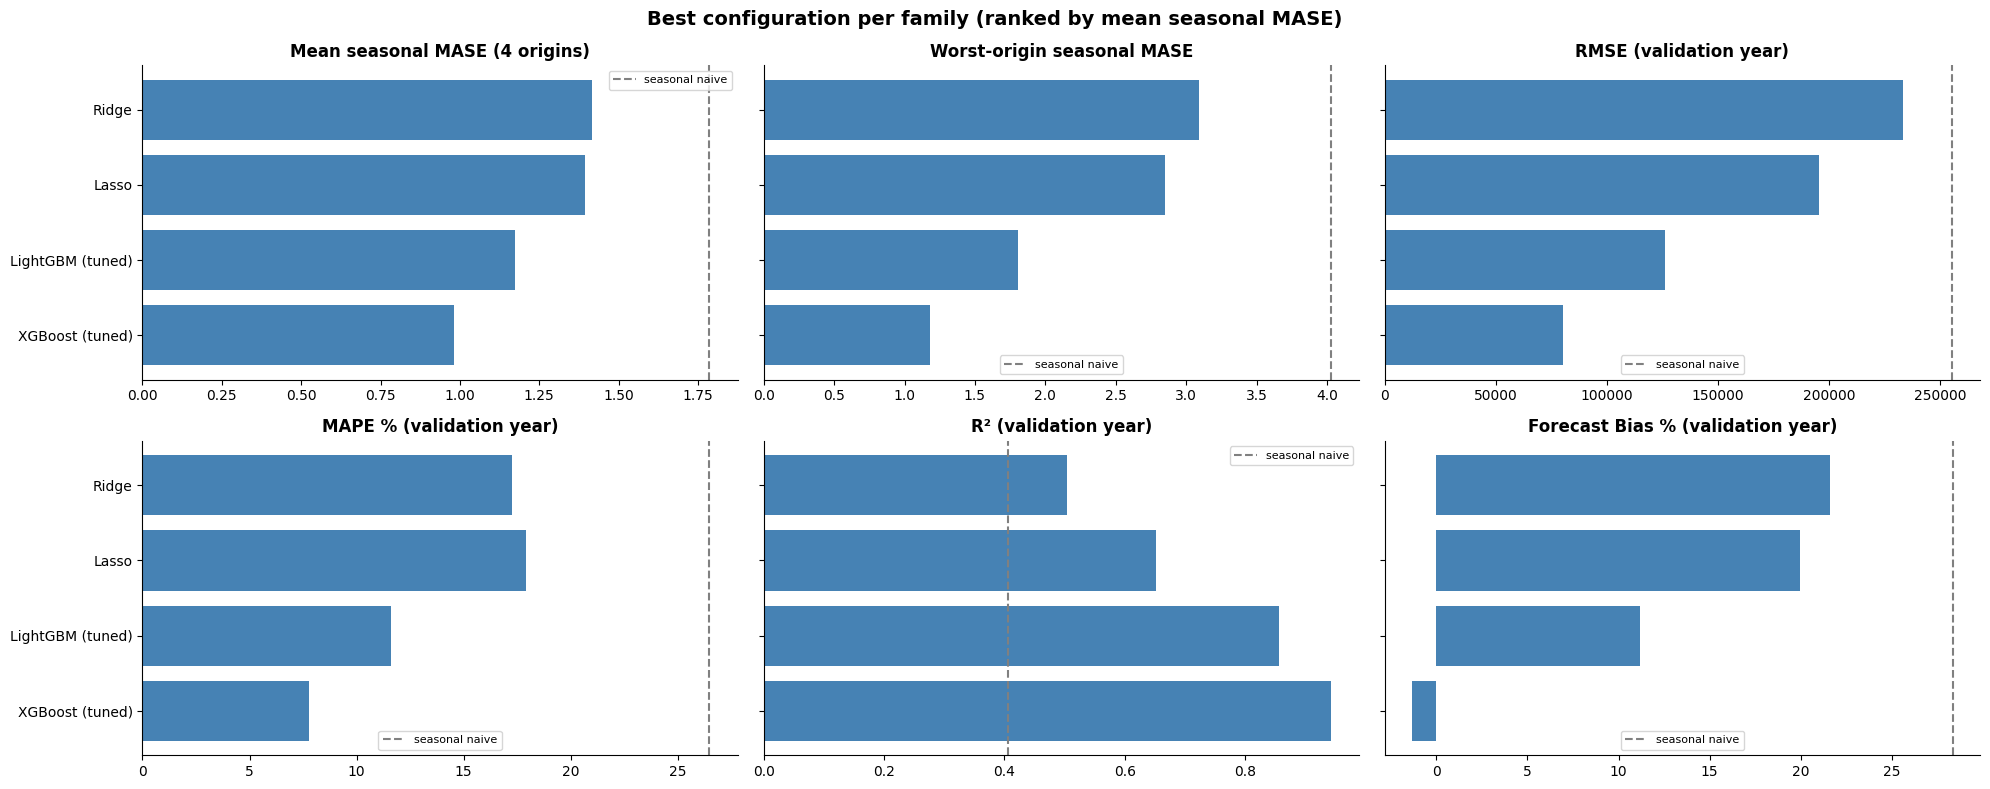

,family,transform,window,covid_rows,strategy,feature_set,tuned,MASE_mean,MASE_worst,MASE_post,n_origins,RMSE,MAE,MAPE,R2,MASE,Forecast Bias,n_trees,alpha,alpha_at_edge
0,ridge,none,all,keep,direct_single,lags+rolling+domain+cal_fourier+elapsed,False,1.417,3.088,2.005,4.0,233625.824,160502.255,17.249,0.503,3.088,21.608,NaN,10.000,0/4
1,lasso,seasonal_log_diff,all,remove,recursive,lags+rolling+domain,False,1.393,2.851,1.795,4.0,195673.147,148163.736,17.901,0.652,2.851,19.957,NaN,0.001,0/4
2,lightgbm,seasonal_log_diff,last_6y,keep,recursive,lags+growth+domain+cal_fourier,True,1.173,1.804,1.375,4.0,126104.129,93741.167,11.627,0.855,1.804,11.170,105.0,NaN,None
3,xgboost,seasonal_log_diff,last_4y,keep,recursive,lags+growth+domain+cal_fourier,True,0.982,1.179,1.055,4.0,80115.966,61259.475,7.788,0.942,1.179,-1.349,141.0,NaN,None


In [17]:
best_per_family = ranked.groupby('family', sort=False).first()
best_per_family = best_per_family.reindex([
    f for f in FAMILIES if f in best_per_family.index
]).reset_index()
best_per_family['label'] = best_per_family['family'].map(FAMILY_NAMES) + np.where(
    best_per_family['tuned'], ' (tuned)', ''
)

BAR_METRICS = ['MASE_mean', 'MASE_worst', 'RMSE', 'MAPE', 'R2', 'Forecast Bias']
METRIC_LABELS = {
    'MASE_mean': f'Mean seasonal MASE ({len(ORIGINS)} origins)',
    'MASE_worst': 'Worst-origin seasonal MASE',
    'RMSE': 'RMSE (validation year)',
    'MAPE': 'MAPE % (validation year)',
    'R2': 'R² (validation year)',
    'Forecast Bias': 'Forecast Bias % (validation year)',
}

fig, axes = plt.subplots(2, 3, figsize=(20, 8), sharey=True)
fig.suptitle(
    'Best configuration per family (ranked by mean seasonal MASE)',
    fontsize=14,
    fontweight='bold',
)
for ax, col in zip(axes.flat, BAR_METRICS):
    title = METRIC_LABELS[col]
    ax.barh(
        best_per_family['label'][::-1], best_per_family[col][::-1], color='steelblue'
    )
    ax.axvline(
        float(baselines.loc['seasonal_naive', col]),
        color='grey',
        linestyle='--',
        label='seasonal naive',
    )
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

best_per_family[
    [*PARAM_KEYS, 'tuned', *AGG_METRICS, *METRICS, 'n_trees', 'alpha', 'alpha_at_edge']
].round(3)

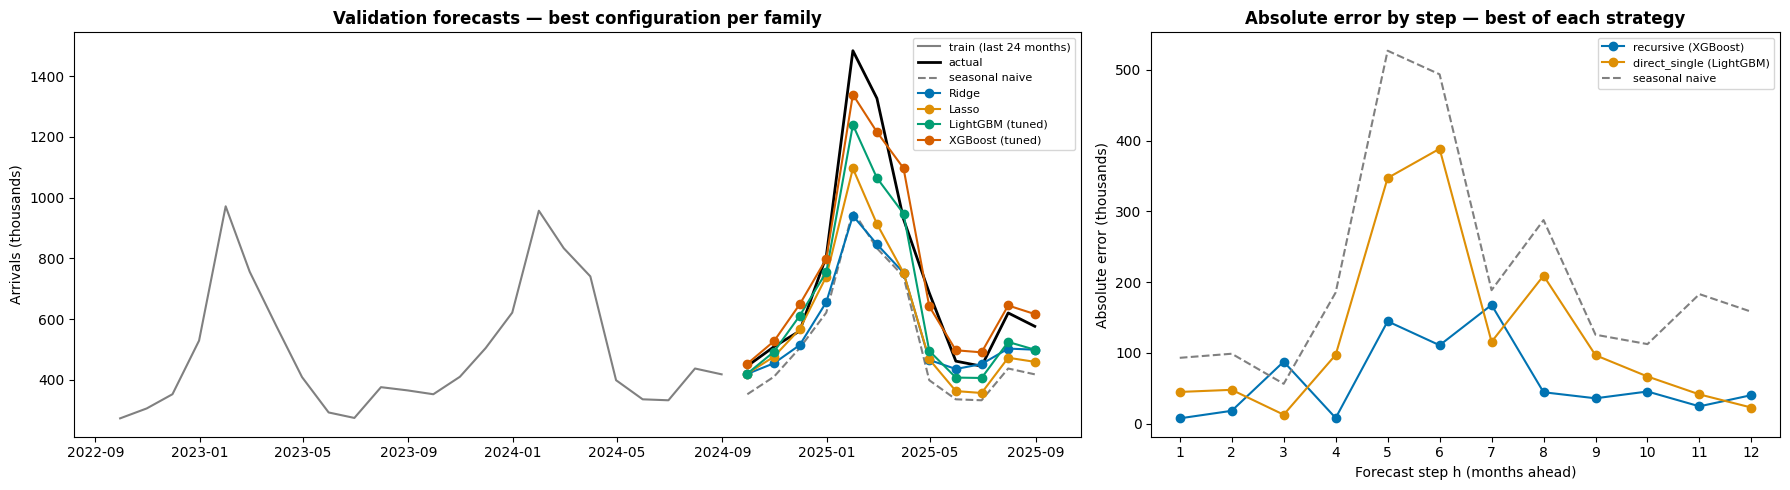

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), gridspec_kw={'width_ratios': [1.6, 1]})
context = train_series.iloc[-24:]
axes[0].plot(context.index, context / 1e3, color='grey', label='train (last 24 months)')
axes[0].plot(
    val_series.index, val_series / 1e3, color='black', linewidth=2, label='actual'
)
axes[0].plot(
    val_series.index,
    baseline_forecasts['seasonal_naive'] / 1e3,
    color='grey',
    linestyle='--',
    label='seasonal naive',
)
for _, row in best_per_family.iterrows():
    axes[0].plot(
        val_series.index, row['prediction'] / 1e3, marker='o', label=row['label']
    )
axes[0].set_title(
    'Validation forecasts — best configuration per family', fontweight='bold'
)
axes[0].set_ylabel('Arrivals (thousands)')
axes[0].legend(fontsize=8)

steps = np.arange(1, HORIZON + 1)
for strategy in STRATEGIES:
    best = ranked[ranked['strategy'] == strategy].iloc[0]
    axes[1].plot(
        steps,
        best['abs_errors'] / 1e3,
        marker='o',
        label=f'{strategy} ({FAMILY_NAMES[best["family"]]})',
    )
axes[1].plot(
    steps,
    np.abs(val_series - baseline_forecasts['seasonal_naive']).to_numpy() / 1e3,
    color='grey',
    linestyle='--',
    label='seasonal naive',
)
axes[1].set_title('Absolute error by step — best of each strategy', fontweight='bold')
axes[1].set_xlabel('Forecast step h (months ahead)')
axes[1].set_ylabel('Absolute error (thousands)')
axes[1].set_xticks(steps)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

### Top 10 Configurations — Validation Forecasts

The same view as notebook 5's *Final Result*: the ten best configurations (by mean seasonal
MASE over the origins), each with the last 24 training months, the actual validation year and
the forecast of the latest origin. The training line is coloured by model family.

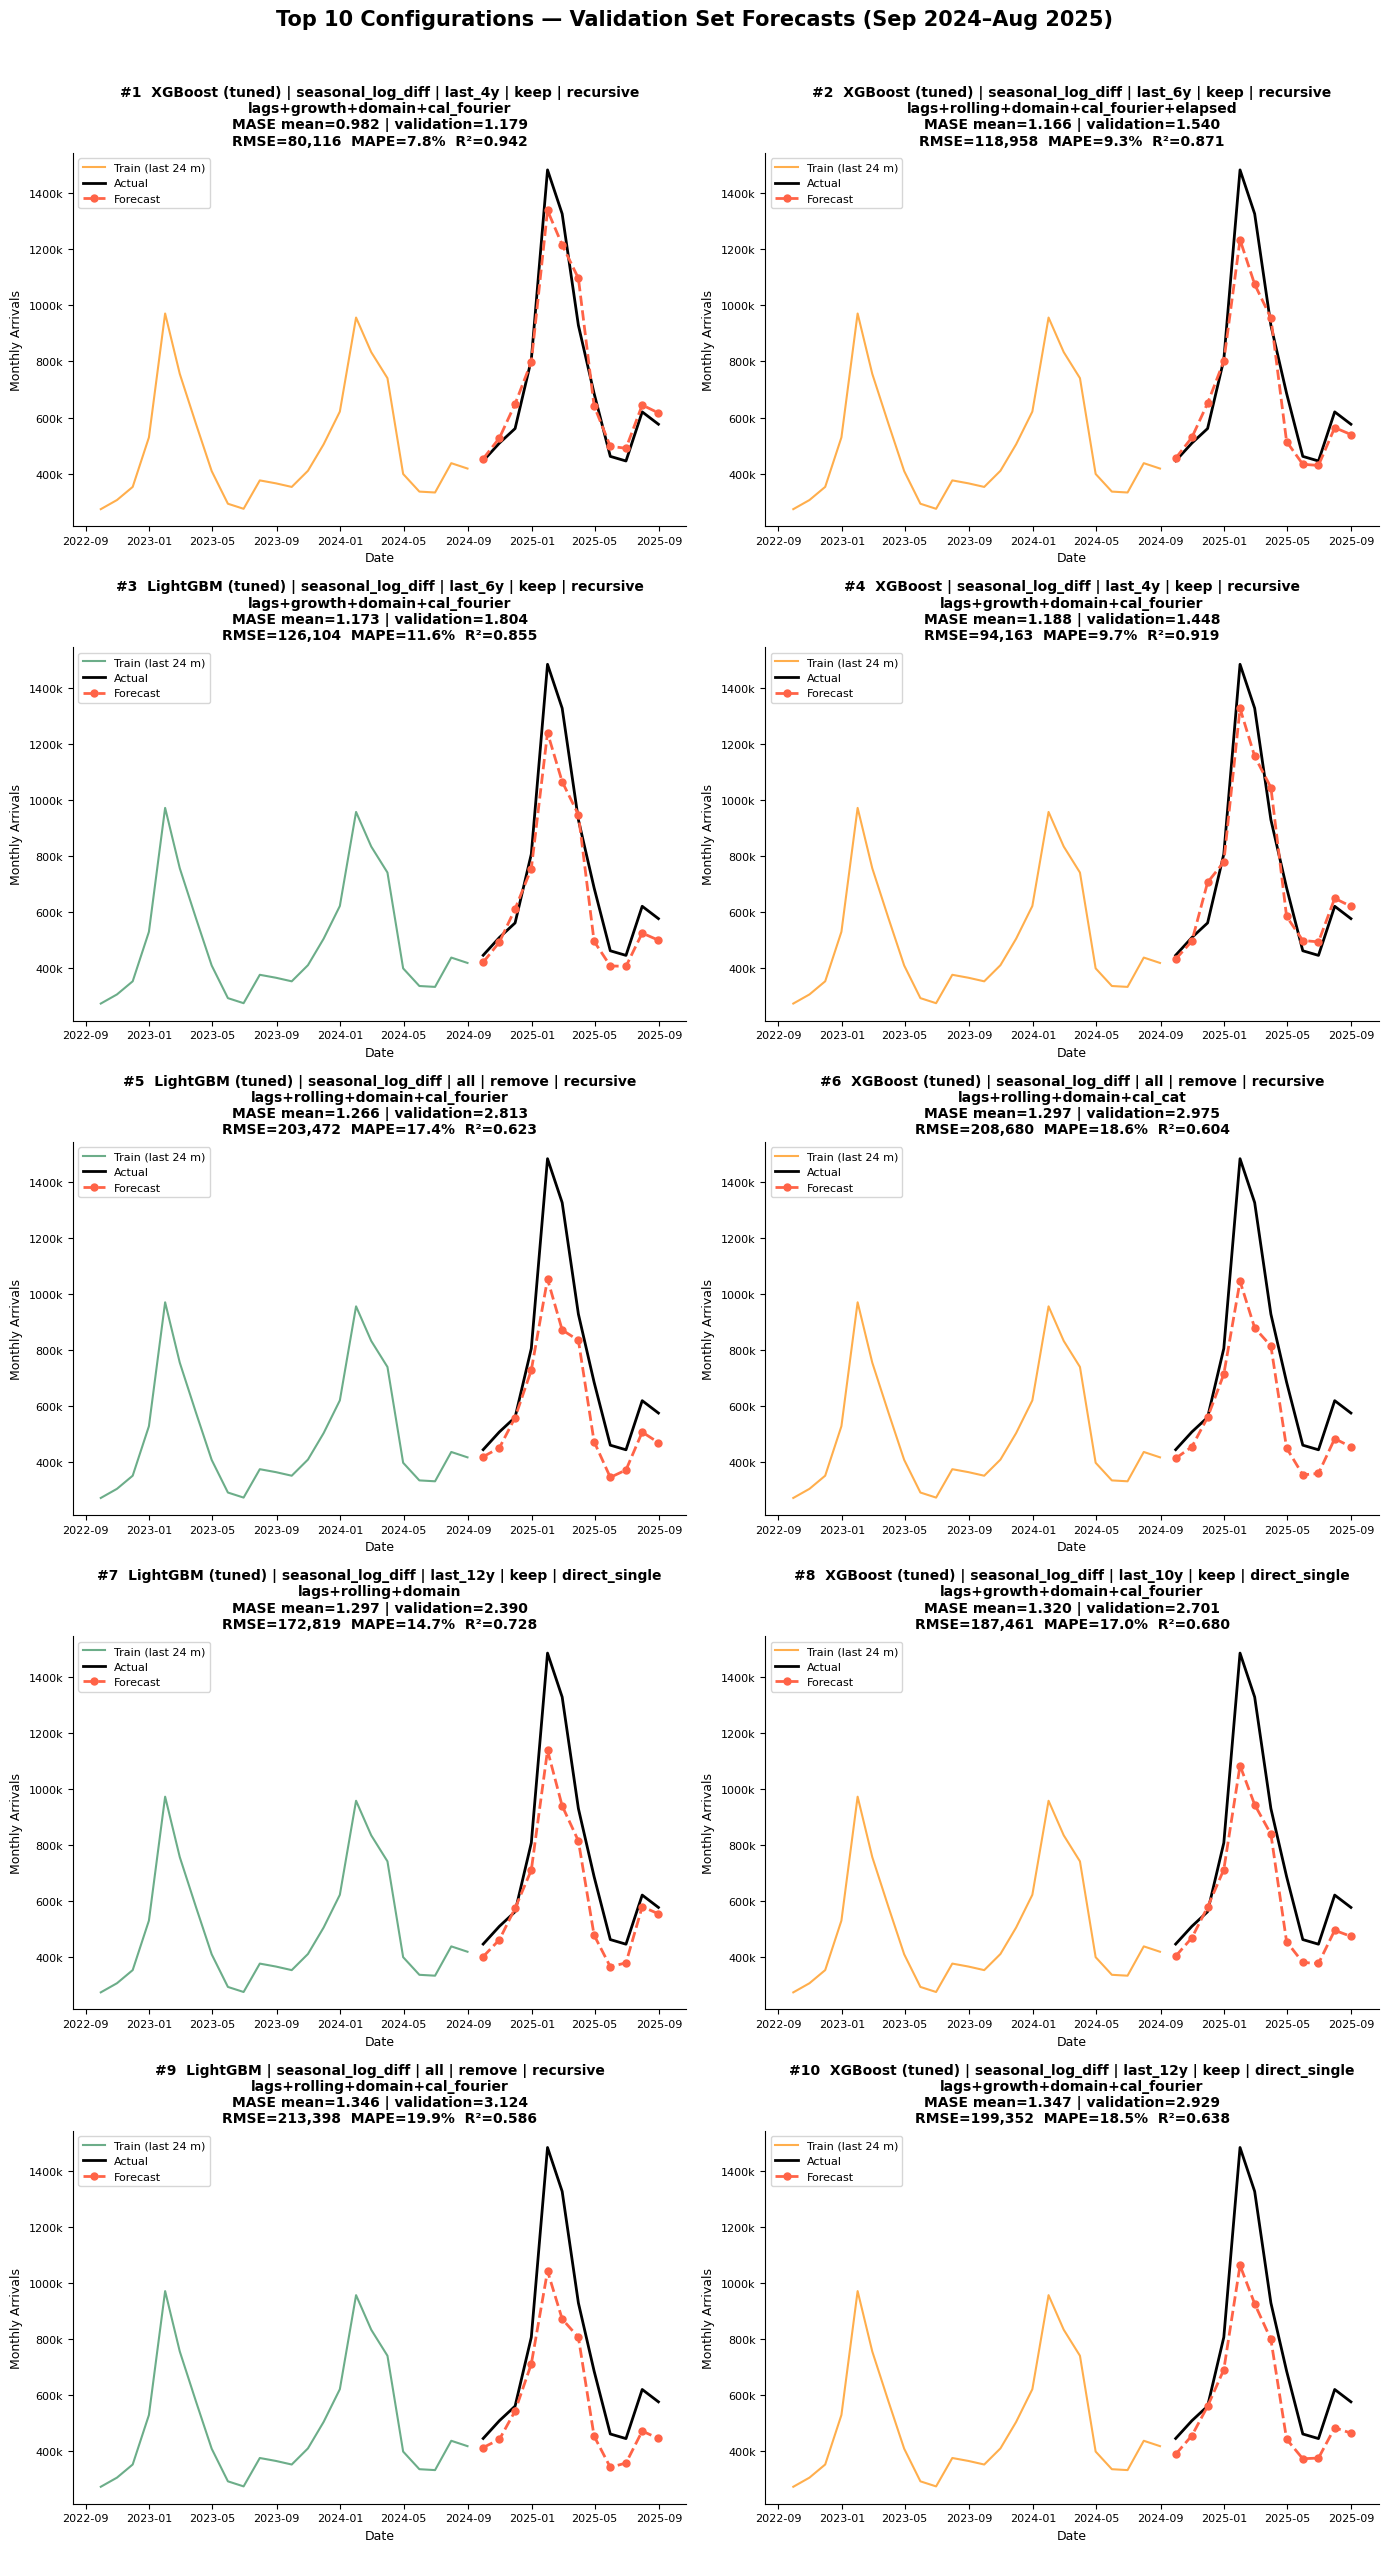

In [19]:
FAMILY_COLORS = {
    'ridge': 'steelblue',
    'lasso': 'mediumpurple',
    'lightgbm': 'seagreen',
    'xgboost': 'darkorange',
}
TOP_N_FORECASTS = 10

top10 = ranked.head(TOP_N_FORECASTS)
train_plot = train_series.iloc[-24:]

fig, axes = plt.subplots(5, 2, figsize=(14, 26))
fig.suptitle(
    f'Top 10 Configurations — Validation Set Forecasts '
    f'({val_series.index[0]:%b %Y}–{val_series.index[-1]:%b %Y})',
    fontsize=15,
    fontweight='bold',
)

for i, (ax, (_, row)) in enumerate(zip(axes.flat, top10.iterrows())):
    ax.plot(
        train_plot.index,
        train_plot.values,
        label='Train (last 24 m)',
        linewidth=1.5,
        color=FAMILY_COLORS[row['family']],
        alpha=0.7,
    )
    ax.plot(
        val_series.index,
        val_series.values,
        label='Actual',
        linewidth=2,
        color='black',
    )
    ax.plot(
        val_series.index,
        row['prediction'],
        label='Forecast',
        linewidth=2,
        linestyle='--',
        color='tomato',
        marker='o',
        markersize=5,
    )

    ax.set_title(
        f'#{i + 1}  {FAMILY_NAMES[row["family"]]}'
        f'{" (tuned)" if row["tuned"] else ""} | '
        f'{row["transform"]} | '
        f'{row["window"]} | {row["covid_rows"]} | {row["strategy"]}\n'
        f'{row["feature_set"]}\n'
        f'MASE mean={row["MASE_mean"]:.3f} | validation={row["MASE"]:.3f}\n'
        f'RMSE={row["RMSE"]:,.0f}  MAPE={row["MAPE"]:.1f}%  R²={row["R2"]:.3f}',
        fontsize=10,
        fontweight='bold',
    )
    ax.set_xlabel('Date', fontsize=9)
    ax.set_ylabel('Monthly Arrivals', fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x / 1000)}k'))
    ax.tick_params(axis='both', labelsize=8)
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

for ax in axes.flat[len(top10) :]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 9. Heatmaps of the Combinations

Each cell summarizes all grid configurations that share the two choices on its axes (every
other choice varies) with the **p95 of the mean seasonal MASE**: the 5% quantile of the cell,
the value that only the best 5% of its configurations beat. Unlike the single best
configuration, it does not reward a combination where one configuration got lucky while its
neighbours are much worse, so it shows which choices are good **reliably**. The tuned runs are
left out, so every cell comes from the same grid. The number under each value is how many
configurations the cell summarizes; with fewer than about 40, the p95 is close to the best
value of the cell.

- Green is better. The colour scale stops at 1.5 × the seasonal naive, so a few exploding
  configurations do not wash out the differences between the good ones.
- `post_covid` is averaged over the two post-COVID origins only (see `MASE_post` to compare
  every window on those origins).
- The best single configurations are in section 8 (ranking, best per family, top 10).

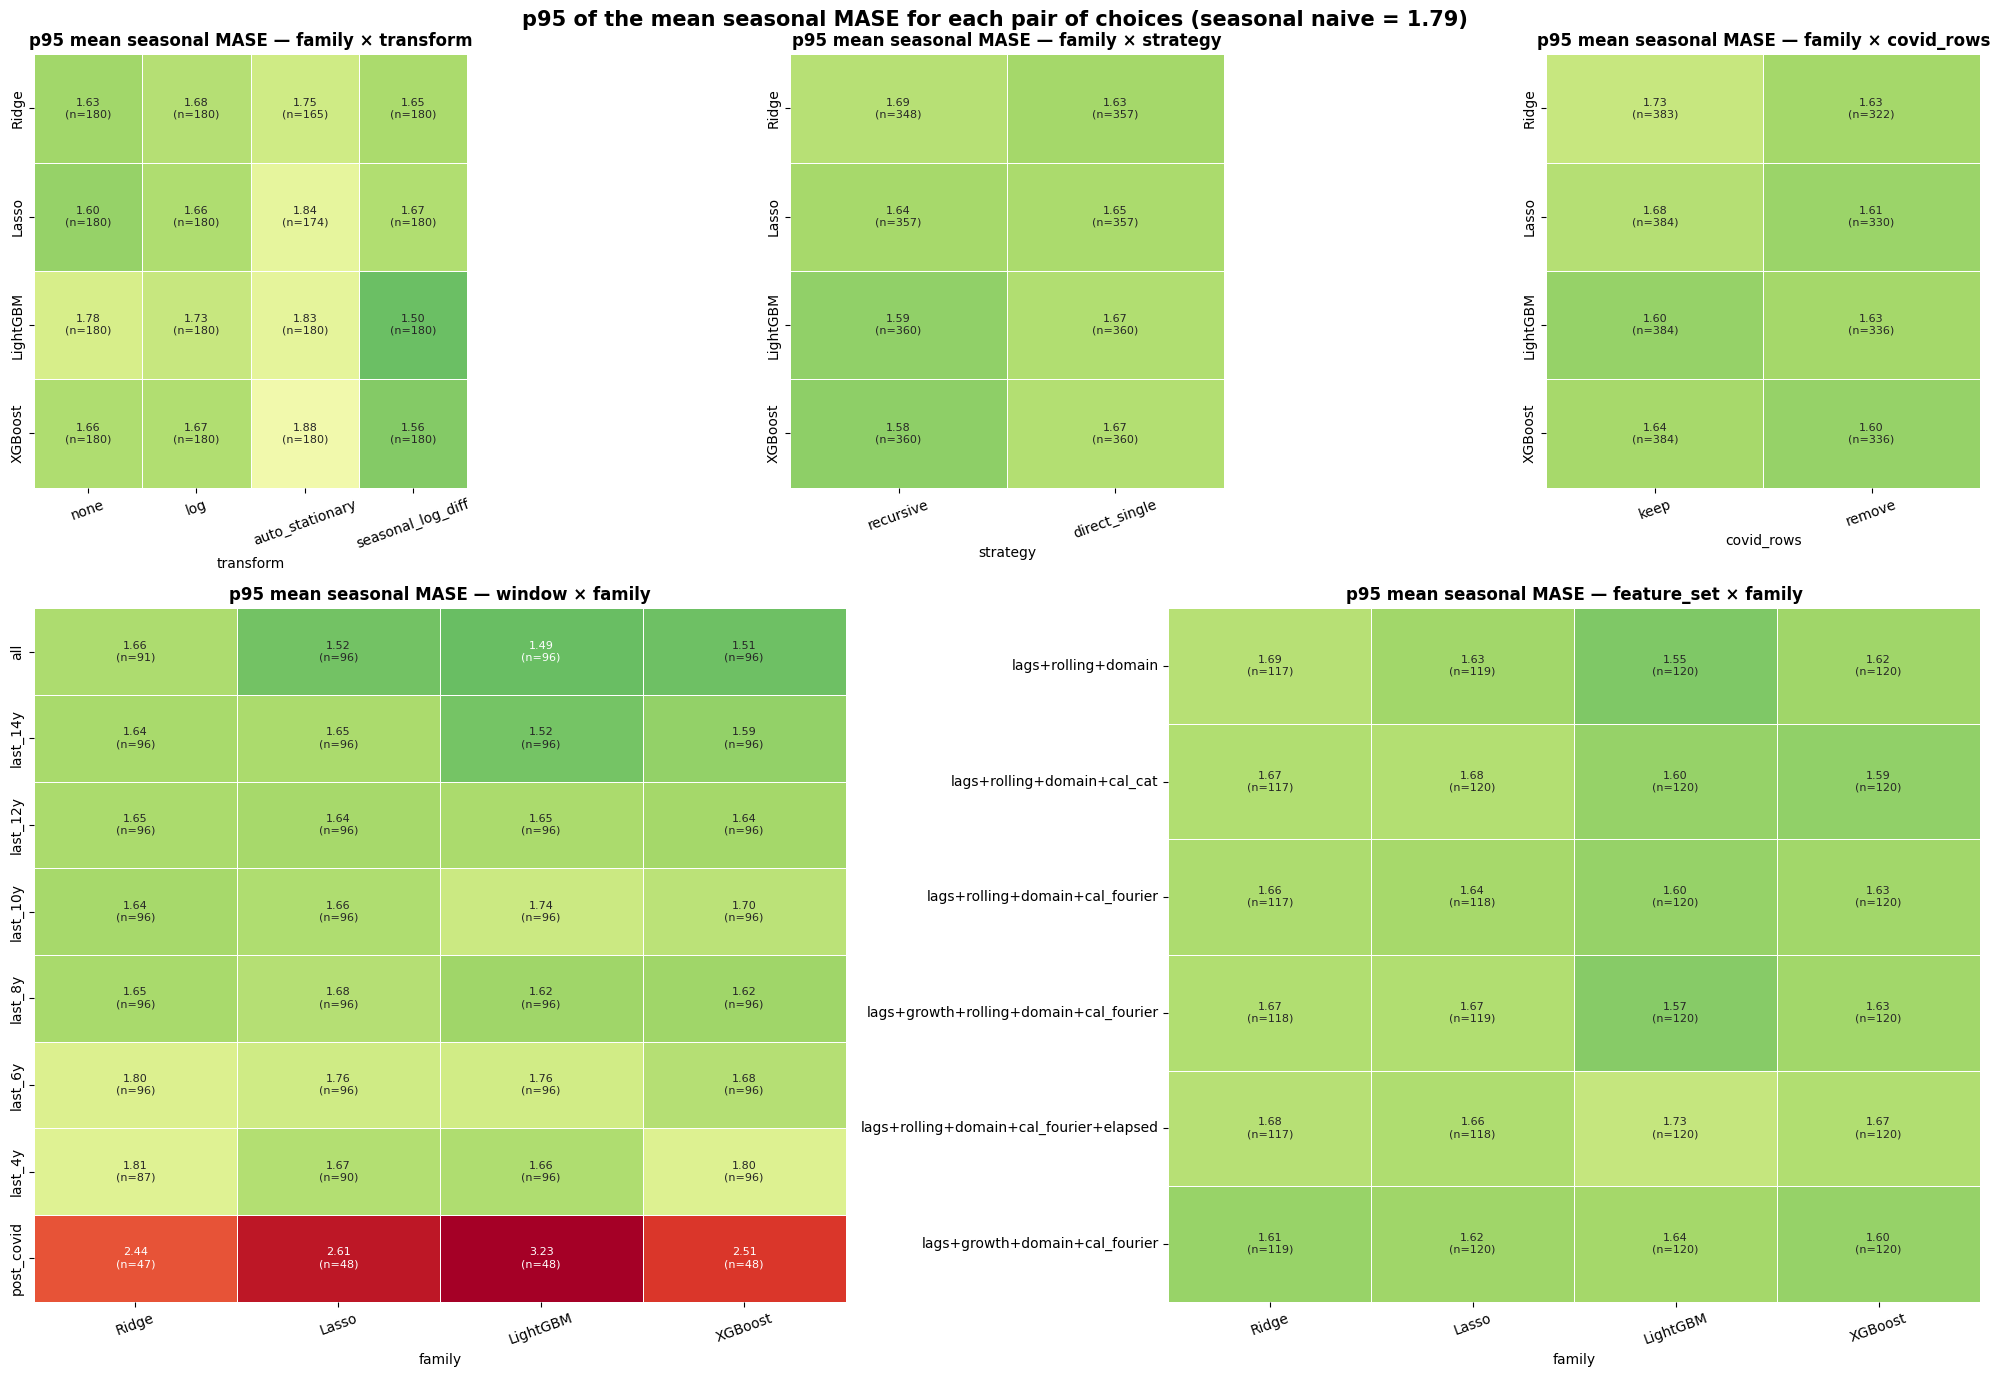

In [20]:
ORDERS = {
    'family': FAMILIES,
    'transform': TARGET_TRANSFORMS,
    'window': list(WINDOWS),
    'covid_rows': COVID_ROWS,
    'strategy': STRATEGIES,
    'feature_set': [set_label(s) for s in FEATURE_SETS],
}
HEATMAP_LAYOUT = [
    # (rows, columns, grid position)
    ('family', 'transform', (0, slice(0, 2))),
    ('family', 'strategy', (0, slice(2, 4))),
    ('family', 'covid_rows', (0, slice(4, 6))),
    ('window', 'family', (1, slice(0, 3))),
    ('feature_set', 'family', (1, slice(3, 6))),
]
MASE_LABEL_CAP = 10
P95_QUANTILE = 0.05  # p95: the value only the best 5% of a cell's configurations beat
grid_ranked = ranked[~ranked['tuned']]


def p95(values):
    return values.quantile(P95_QUANTILE)


def mase_label(value, count):
    if pd.isna(value):
        return ''
    shown = f'>{MASE_LABEL_CAP}' if value > MASE_LABEL_CAP else f'{value:.2f}'
    return f'{shown}\n(n={int(count)})'


def p95_mase_pivot(rows, columns):
    """p95 of the mean seasonal MASE per cell, and the configurations per cell."""
    frames = [
        grid_ranked.pivot_table(
            index=rows, columns=columns, values='MASE_mean', aggfunc=aggfunc
        ).reindex(
            index=[v for v in ORDERS[rows] if v in grid_ranked[rows].unique()],
            columns=[v for v in ORDERS[columns] if v in grid_ranked[columns].unique()],
        )
        for aggfunc in (p95, 'count')
    ]
    if rows == 'family':
        frames = [frame.rename(index=FAMILY_NAMES) for frame in frames]
    if columns == 'family':
        frames = [frame.rename(columns=FAMILY_NAMES) for frame in frames]
    pivot, counts = frames
    labels = pd.DataFrame(
        [
            [mase_label(v, n) for v, n in zip(values, ns)]
            for values, ns in zip(pivot.to_numpy(), counts.to_numpy())
        ],
        index=pivot.index,
        columns=pivot.columns,
    )
    return pivot, labels


fig = plt.figure(figsize=(20, 14))
grid = fig.add_gridspec(2, 6, height_ratios=[1, 1.6])
for rows, columns, (r, c) in HEATMAP_LAYOUT:
    ax = fig.add_subplot(grid[r, c])
    pivot, labels = p95_mase_pivot(rows, columns)
    sns.heatmap(
        pivot,
        annot=labels,
        fmt='',
        annot_kws={'fontsize': 8},
        cmap='RdYlGn_r',
        vmin=grid_ranked['MASE_mean'].min(),
        vmax=BASELINE_MASE * 1.5,
        linewidths=0.4,
        cbar=False,
        ax=ax,
    )
    ax.set_title(f'p95 mean seasonal MASE — {rows} × {columns}', fontweight='bold')
    ax.set_xlabel(columns)
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelrotation=20)
fig.suptitle(
    'p95 of the mean seasonal MASE for each pair of choices '
    f'(seasonal naive = {BASELINE_MASE:.2f})',
    fontsize=15,
    fontweight='bold',
)
plt.tight_layout()
plt.show()

## 10. Feature Importance of the Best Configuration per Family

The best configuration of each family is refitted at the latest origin (trained up to the end
of training, with its tuned parameters if it was tuned) to inspect what it relies on.

- **Native importance** (`MLForecast.feature_importance()`): coefficients for the linear
  models (comparable because `normalize=True`; Lasso's zeros are the features it dropped) and
  the built-in importance of the tree models.
- **Permutation importance by group** on the validation year (the book's most reliable
  measure). All columns of a group are shuffled together (for example the `sin` and `cos` of one
  frequency), the model predicts again and the MAE increase is measured. The features are built
  from the actual validation history (teacher forcing), so every model is scored on the rows it
  would see at its own shift. `MLForecast` is not a full scikit-learn estimator, so the
  permutation is done by hand.

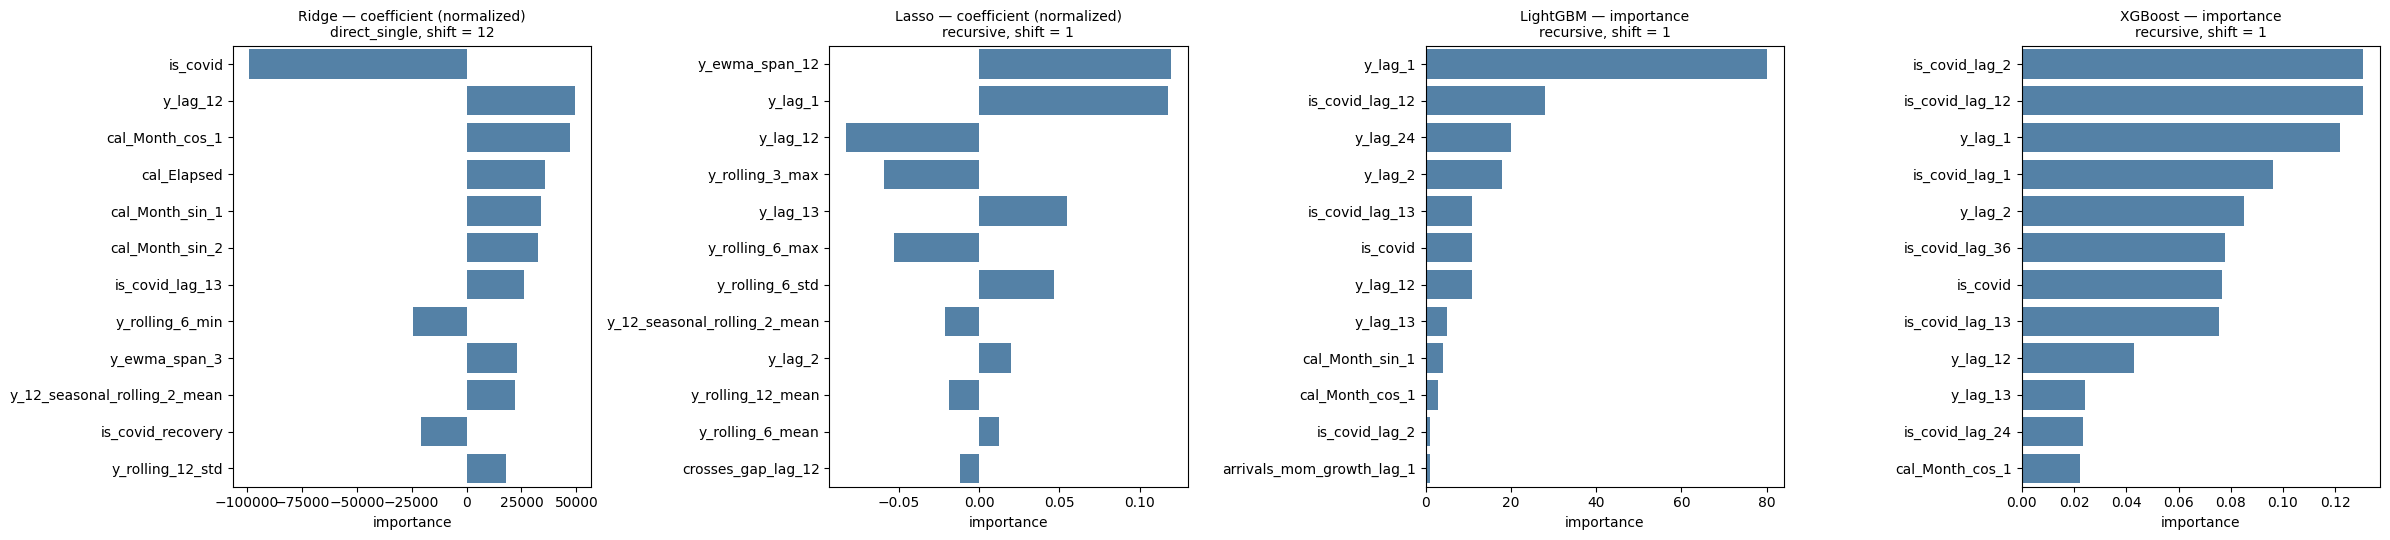

In [21]:
def refit(row):
    config = row_config(row)
    tree_params = row['tree_params'] if isinstance(row['tree_params'], dict) else None
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        _, models = forecast_arrivals(
            config, setup_for(config, LATEST_ORIGIN), tree_params
        )
    return config, models


best_models = {row['family']: refit(row) for _, row in best_per_family.iterrows()}

TOP_FEATURES = 12
fig, axes = plt.subplots(1, len(best_models), figsize=(24, 5.5))
for ax, family in zip(np.atleast_1d(axes), best_models):
    config, models = best_models[family]
    shift, (model, _) = next(iter(models.items()))
    importance = model.feature_importance().head(TOP_FEATURES)
    sns.barplot(data=importance, x='importance', y='feature', ax=ax, color='steelblue')
    kind = 'importance' if family in TREE_FAMILIES else 'coefficient (normalized)'
    ax.set_title(
        f'{FAMILY_NAMES[family]} — {kind}\n{config.strategy}, shift = {shift}',
        fontsize=10,
    )
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

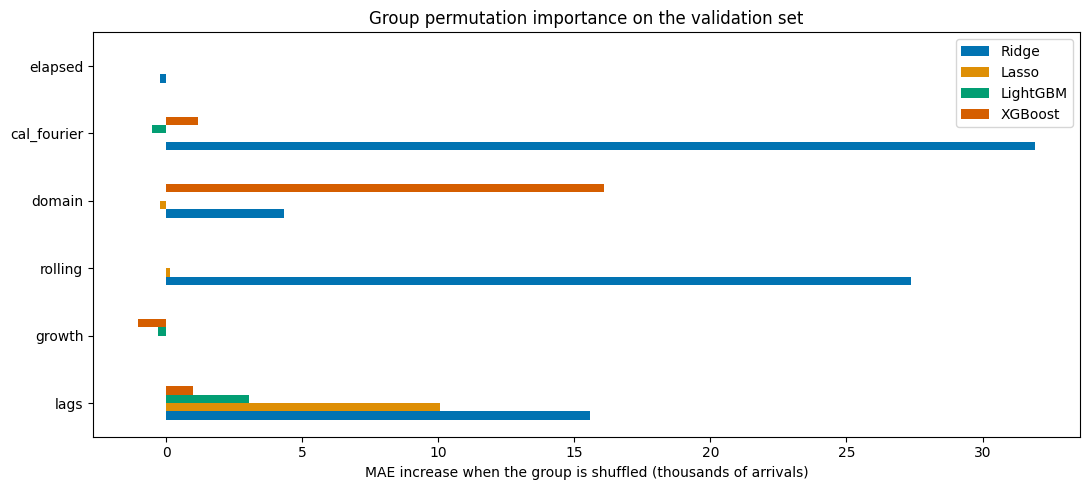

,Ridge,Lasso,LightGBM,XGBoost
lags,15560.0,10057.0,3044.0,996.0
growth,NaN,NaN,-317.0,-1042.0
rolling,27380.0,134.0,NaN,NaN
domain,4340.0,-225.0,0.0,16071.0
cal_fourier,31933.0,NaN,-508.0,1158.0
elapsed,-220.0,NaN,NaN,NaN


In [22]:
N_REPEATS = 30


def group_permutation_importance(config, models, n_repeats=N_REPEATS):
    """Validation MAE increase when the columns of a group are shuffled together."""
    setup = setup_for(config, LATEST_ORIGIN)
    observed = pd.concat([setup['train_part'], val_series])
    full = make_history(setup['transformer'].transform(observed), observed)
    rng = np.random.default_rng(RANDOM_STATE)
    increases = {group: [] for group in config.feature_set}
    for shift, (model, feature_config) in models.items():
        features, groups = build_features(full, shift)
        rows = features[features['date'].isin(val_series.index)].reset_index(drop=True)

        def mae_of(frame):
            predicted_z = predict_rows(model, feature_config, frame, config.feature_set)
            predicted = to_arrivals(
                setup, pd.Series(predicted_z.to_numpy(), index=val_series.index)
            )
            return float(np.mean(np.abs(val_series.to_numpy() - predicted.to_numpy())))

        base = mae_of(rows)
        for group in config.feature_set:
            scores = []
            for _ in range(n_repeats):
                shuffled = rows.copy()
                order = rng.permutation(len(rows))
                shuffled[groups[group]] = (
                    rows[groups[group]].iloc[order].set_axis(rows.index)
                )
                scores.append(mae_of(shuffled) - base)
            increases[group].append(np.mean(scores))
    return pd.Series({group: np.mean(values) for group, values in increases.items()})


with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    permutation = (
        pd
        .DataFrame({
            FAMILY_NAMES[family]: group_permutation_importance(*best_models[family])
            for family in best_models
        })
        .reindex(GROUP_ORDER)
        .dropna(how='all')
    )

ax = (permutation / 1e3).plot.barh(figsize=(11, 5))
ax.set_title('Group permutation importance on the validation set')
ax.set_xlabel('MAE increase when the group is shuffled (thousands of arrivals)')
plt.tight_layout()
plt.show()
permutation.round(0)

## 11. Save the Best Configuration's Validation Forecasts

The ensembling notebook (10) combines the best configuration of every approach, so it needs
their **forecasts**, not only their metrics. The best configuration of this notebook (rank 1 by
mean seasonal MASE, tuned or not) is re-run at every validation origin with its tuned tree parameters if it was tuned (the fits are deterministic), and its forecasts
are logged as the artifact `validation_forecasts.csv` of a run tagged
`role = best_validation_forecasts` in this notebook's experiment:

| Column | Content |
|---|---|
| `origin` | the validation origin (`YYYY-MM`) |
| `date` | the forecast month |
| `actual` | the actual total arrivals |
| `forecast` | the forecast of the total |

The mean seasonal MASE of these forecasts must match the ranking, which is checked before
logging. The run has no `eval_split` parameter, so the comparison queries of the other
notebooks do not pick it up as a grid run.

In [23]:
best = ranked.iloc[0]
best_config = row_config(best)
best_tree_params = (
    best['tree_params'] if isinstance(best['tree_params'], dict) else None
)
origin_results = evaluate_origins(best_config, best_tree_params)
assert all(r['error'] is None for r in origin_results)

best_forecasts = pd.concat(
    [
        pd.DataFrame({
            'origin': origin_label(r['origin']),
            'date': val_actual_at(r['origin']).index,
            'actual': val_actual_at(r['origin']).to_numpy(),
            'forecast': r['prediction'],
        })
        for r in origin_results
    ],
    ignore_index=True,
)
mase_mean = float(np.mean([r['MASE'] for r in origin_results]))
assert np.isclose(mase_mean, best['MASE_mean']), (mase_mean, best['MASE_mean'])


def log_validation_forecasts(approach, configuration, forecasts, mase_mean):
    """Log the best configuration's forecasts at every origin as an MLflow artifact."""
    with mlflow.start_run(
        run_name=f'BEST validation forecasts | {configuration}'[:250]
    ):
        mlflow.set_tags({'role': 'best_validation_forecasts', 'approach': approach})
        mlflow.log_params({
            'configuration': configuration[:500],
            'origins': ', '.join(sorted(forecasts['origin'].unique())),
            'horizon': HORIZON,
        })
        mlflow.log_metric('MASE_mean', mase_mean)
        mlflow.log_text(forecasts.to_csv(index=False), 'validation_forecasts.csv')
    print(f'{approach}: logged {len(forecasts)} forecasts of {configuration}')


label = best_config.label + (' | tuned' if best['tuned'] else '')
log_validation_forecasts('Local ML', label, best_forecasts, mase_mean)

Local ML: logged 48 forecasts of XGBoost | seasonal_log_diff | last_4y | keep | recursive | lags+growth+domain+cal_fourier | tuned


## Reading the Results

| Question | Where |
|---|---|
| Does any ML model beat the seasonal naive? | `beats_seasonal_naive` in section 8, the dashed lines of the bar charts |
| Which family and target processing work best? | Heatmap *family × transform* |
| Does `seasonal_log_diff` fix the trees' extrapolation limit? | Heatmap *family × transform*, tree rows |
| Which multi-step strategy suits each family? | Heatmap *family × strategy* and the error-by-step curves |
| Does removing the pandemic years help? | Heatmap *family × covid_rows* |
| How much history should a model see? | Heatmap *window × family* |
| Which feature groups matter? | Heatmap *feature_set × family* and the group permutation importance |
| Does tuning help the trees? | The Optuna table in section 8 (grid vs tuned `MASE_mean`) |
| How does ML compare with SARIMAX? | Section 8 metrics against notebook 5 (same origins, metrics and baselines) |

Things to keep in mind:

- **Selection on validation data.** Four origins (48 months) make the selection much more
  robust than one validation year, but the best of thousands of configurations is still
  optimistic. Compare families and choices through the heatmaps (p95, robust to lucky
  single configurations) and `MASE_worst` rather than through a single top score; the unbiased score comes from the test year in the final notebook.
- **Stability.** A configuration with a good mean but a bad worst origin is fragile; prefer a
  slightly worse mean with a much better worst case.
- **Trees and levels.** If the tree models only do well with `log`, `auto_stationary` or
  `seasonal_log_diff`, that is their extrapolation limit: on the raw scale they cannot forecast
  above the training maximum.
- **Linear penalties on the edge.** `alpha_at_edge` counts the origins where the chosen penalty
  hit the end of its grid; if it happens often, the alpha grid should be widened.